# Исследовательский анализ данных и предоработка

In [173]:
import numpy as np
import itertools
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu, kruskal, chi2_contingency
from itertools import combinations
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error

### Чтение файла. Приведение названий столбцов в соответствии с PEP8

In [174]:
df = pd.read_csv('ecom_yl.csv',  sep=',', encoding='utf-8')
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

### Проверка на пропуски

In [175]:
print("Количество строк: ", len(df))
df.info()

Количество строк:  1012
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             1012 non-null   int64  
 1   region              999 non-null    object 
 2   device              999 non-null    object 
 3   channel             999 non-null    object 
 4   session_start       1012 non-null   object 
 5   session_end         1012 non-null   object 
 6   sessiondurationsec  1012 non-null   float64
 7   session_date        1012 non-null   object 
 8   month               1012 non-null   int64  
 9   day                 1012 non-null   int64  
 10  hour_of_day         1012 non-null   int64  
 11  order_dt            285 non-null    object 
 12  revenue             285 non-null    float64
 13  payment_type        285 non-null    object 
 14  promo_code          285 non-null    float64
dtypes: float64(3), int64(4), object

Всего в датасете 1012 строк.
Ненулевых строк в стобцах "order_dt", "revenue", "payment_type", "promo_code" по 285 шт.
Это обоснованно, так как не каждый пользователь совершает покупку.

В "region", "device", "channel" по 999 ненулевые строки. Это действительно пропуски.
Так как эти параметры категориальные, мы не можем заменить их средним значение, медианой и т.д. Попытка заполнить пропуски приведет к искажению данных. 
(Если бы пропуски были распределены равномерно в каждом стобце, может и стоило заполнить данные. Но так как предположительно это 13 строк с пропусками СРАЗУ в трех столбцах (и нам не на что опираться в их заполнении), 
заполнять пропуски не стоит.)

Следовательно, просто исключим строки с пропусками. 

In [176]:
print("Количество строк с пропусками:", 
      len(df[(df['region'].isna() == True) | (df['device'].isna() == True) | (df['channel'].isna() == True)]))

df_clean = df[(df['region'].isna() == False) & (df['device'].isna() == False) & (df['channel'].isna() == False )].copy()                                                              
print("Количество строк БЕЗ пропусков:", len(df_clean))

Количество строк с пропусками: 13
Количество строк БЕЗ пропусков: 999


Объем данных для анализа сократился на 13 строк. (Подробнее с блоке "Статистика")

### Проверка на дубликаты

In [177]:
# проверяем данные на дубликаты (НЕявные)

print(df_clean['region'].unique(), '\n')
print(df_clean['device'].unique(), '\n')
print(df_clean['channel'].unique(), '\n')
print(df_clean['payment_type'].unique())

['United States' 'Frаnce' 'Unjted States' 'Germany' 'UK' 'France' 'Frаncе'
 'Franсe' 'germany' 'UК'] 

['iPhone' 'PC' 'Mac' 'Android' 'android'] 

['социальные сети' 'organic' 'реклама у блогеров' 'контексная реклама'
 'email-рассылки' 'контекстная реклама'] 

['Mobile payments' nan 'Debit card' 'E-wallet' 'Cash' 'Credit card']


В данных присутствуют неявные дубликаты. (Символы выглядят одинаково, но их код разный). Избавимся от них, явно заменив с помощью replace.

In [178]:
df_clean['region'] = (
    df_clean['region']
    .replace('Frаnce','France')
    .replace('France','France')
    .replace('Frаncе','France')
    .replace('Franсe','France')
    .replace('UK','UK')
    .replace('UК','UK')
    .replace('Unjted States','United States')
    .replace('germany','Germany')
)
df_clean['device'] = df_clean['device'].replace('android', 'Android')
df_clean['channel'] = df_clean['channel'].replace('контексная реклама', 'контекстная реклама')

In [179]:
print ("ПОСЛЕ ИЗМЕНЕНИЙ\n")
print(df_clean['region'].unique(), '\n')
print(df_clean['device'].unique(), '\n')
print(df_clean['channel'].unique(), '\n')
print(df_clean['payment_type'].unique())

ПОСЛЕ ИЗМЕНЕНИЙ

['United States' 'France' 'Germany' 'UK'] 

['iPhone' 'PC' 'Mac' 'Android'] 

['социальные сети' 'organic' 'реклама у блогеров' 'контекстная реклама'
 'email-рассылки'] 

['Mobile payments' nan 'Debit card' 'E-wallet' 'Cash' 'Credit card']


После замены неявные дубликаты были устранены, данные остались в том же объеме.

In [180]:
# проверяем данные на дубликаты (явные)

print("Количество дубликатов (полностью строка):", df_clean.duplicated().sum())

df_clean = df_clean[df_clean.duplicated() == False]
print("Количество строк без дубликатов (всех):", len(df_clean))
df = df_clean

Количество дубликатов (полностью строка): 2
Количество строк без дубликатов (всех): 997


Объем данных для анализа сократился на 2 строки. (Подробнее с блоке "Статистика")

### Проверка на выбросы и адекватность

In [181]:
print(df.groupby('revenue').size())

revenue
1.0           2
4999.0      185
5999.0       66
9999.0       18
100000.0      4
dtype: int64


В данных присутствуют как очень маленькие значения (1), так и очень большие (100 000).
Мы не можем утверждать, что значения "100 000" выбросы, а не крупные покупки, поэтому эти данные не изменяем. Однако "1" является выбросом и требует замену.

Среднее значение в данном случае будет завышено из-за неравномерности данных. Следовательно, заменять будем на медианное значение, которое устойчиво к выбросам.

In [182]:
median_revenue = df['revenue'].median()
print("Медианное значение:", median_revenue)

df['revenue'] = df['revenue'].apply(lambda x: median_revenue if x <=1 else x)
print(df.groupby('revenue').size())

Медианное значение: 4999.0
revenue
4999.0      187
5999.0       66
9999.0       18
100000.0      4
dtype: int64


In [183]:
print(df.groupby('promo_code').size())

promo_code
0.000000    196
0.862715      2
1.000000     77
dtype: int64


Это бинарная шкала, значения 0.862715 явно ошибочны. Заменим их на 0.

In [184]:
df['promo_code'] = (df['promo_code'] == 1).astype(int)
print(df.groupby('promo_code').size())

promo_code
0    920
1     77
dtype: int64


### Приведение данных соответствующий формат

In [185]:
df['session_start'] = pd.to_datetime(df['session_start'])
df['session_end'] = pd.to_datetime(df['session_end'])
df['session_date'] = pd.to_datetime(df['session_date'])
# df['sessiondurationsec'] = pd.to_datetime(df['sessiondurationsec'])
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['promo_code'] = df['promo_code'].astype(str)

In [186]:
# проверим, что данные в нужном формате 

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             997 non-null    int64         
 1   region              997 non-null    object        
 2   device              997 non-null    object        
 3   channel             997 non-null    object        
 4   session_start       997 non-null    datetime64[ns]
 5   session_end         997 non-null    datetime64[ns]
 6   sessiondurationsec  997 non-null    float64       
 7   session_date        997 non-null    datetime64[ns]
 8   month               997 non-null    int64         
 9   day                 997 non-null    int64         
 10  hour_of_day         997 non-null    int64         
 11  order_dt            275 non-null    datetime64[ns]
 12  revenue             275 non-null    float64       
 13  payment_type        275 non-null    object        
 14

### Добавление столбцов

In [187]:
# Итоговая сумма покупки с учетом применения промокода на скидку 10%

df['final_revenue'] = df['revenue']
for index, row in df.iterrows():
    if row['promo_code'] == 1:
        df.loc[index, 'final_revenue'] = df.loc[index, 'revenue'] * 0.9

In [188]:
# Время суток визита

df['day_time'] = ''
for index, row in df.iterrows():
    if (row['hour_of_day'] >= 6) and (row['hour_of_day'] < 10):
        df.loc[index, 'day_time'] = 'утро'
    elif (row['hour_of_day'] >= 10) and (row['hour_of_day'] < 17):
        df.loc[index, 'day_time'] = 'день'
    elif (row['hour_of_day'] >= 17) and (row['hour_of_day'] < 22):
        df.loc[index, 'day_time'] = 'вечер'
    else:
        df.loc[index, 'day_time'] = 'ночь'

In [189]:
# Является ли пользователь платящим или нет

df['payer'] = df['order_dt'].apply(lambda x: 0 if pd.isna(x) else 1)

In [190]:
# проверка добавления столбцов

df.iloc[20:30]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,final_revenue,day_time,payer
20,771147371911,United States,Android,organic,2019-05-06 15:49:16,2019-05-06 15:53:16,240.0,2019-05-06,5,1,15,2019-05-06 15:49:16,4999.0,Mobile payments,0,4999.0,день,1
21,200229116069,United States,iPhone,социальные сети,2019-05-06 14:41:29,2019-05-06 15:03:05,1296.0,2019-05-06,5,1,15,NaT,NaN,NaN,0,NaN,день,0
22,211508838415,UK,PC,реклама у блогеров,2019-05-06 15:01:55,2019-05-06 15:01:58,3.0,2019-05-06,5,1,15,NaT,NaN,NaN,0,NaN,день,0
23,587910441297,United States,Android,organic,2019-05-06 22:17:39,2019-05-07 00:23:00,7521.0,2019-05-06,5,1,0,NaT,NaN,NaN,0,NaN,ночь,0
24,777113558856,United States,PC,organic,2019-05-06 02:42:53,2019-05-06 02:57:32,879.0,2019-05-06,5,1,2,NaT,NaN,NaN,0,NaN,ночь,0
25,880458590199,United States,Mac,organic,2019-05-06 09:32:33,2019-05-06 09:37:03,270.0,2019-05-06,5,1,9,NaT,NaN,NaN,0,NaN,утро,0
26,885616229665,Germany,Mac,email-рассылки,2019-05-06 17:57:38,2019-05-06 18:20:47,1389.0,2019-05-06,5,1,18,NaT,NaN,NaN,0,NaN,вечер,0
27,4194358516,France,iPhone,organic,2019-05-07 20:04:41,2019-05-07 20:12:13,452.0,2019-05-07,5,2,20,NaT,NaN,NaN,0,NaN,вечер,0
28,245941309860,Germany,Mac,organic,2019-05-07 12:00:49,2019-05-07 13:10:26,4177.0,2019-05-07,5,2,13,2019-05-07 12:01:43,4999.0,Mobile payments,1,4999.0,день,1
29,70714916898,United States,Android,organic,2019-05-07 14:01:14,2019-05-07 14:26:18,1504.0,2019-05-07,5,2,14,NaT,NaN,NaN,0,NaN,день,0


In [191]:
# Статистика
total_rows_initial = 1012
final_rows = len(df)

null_rows = 13  
duplicate_count = 2

null_percentage = (null_rows / total_rows_initial) * 100
duplicate_percentage = (duplicate_count / (total_rows_initial - null_rows)) * 100
data_loss_percentage = ((total_rows_initial - final_rows) / total_rows_initial) * 100

print(f"1. Исходный объём данных: {total_rows_initial} строк")
print(f"2. Удалено строк с пропусками: {null_rows} ({null_percentage:.1f}%)")
print(f"3. Удалено полных дубликатов: {duplicate_count} ({duplicate_percentage:.1f}%)")
print(f"4. Общие потери данных: {total_rows_initial - final_rows} строк ({data_loss_percentage:.1f}%)")
print(f"5. Осталось для анализа: {final_rows} строк ({100 - data_loss_percentage:.1f}% от исходных)")

1. Исходный объём данных: 1012 строк
2. Удалено строк с пропусками: 13 (1.3%)
3. Удалено полных дубликатов: 2 (0.2%)
4. Общие потери данных: 15 строк (1.5%)
5. Осталось для анализа: 997 строк (98.5% от исходных)


### Определение исследуемого периода

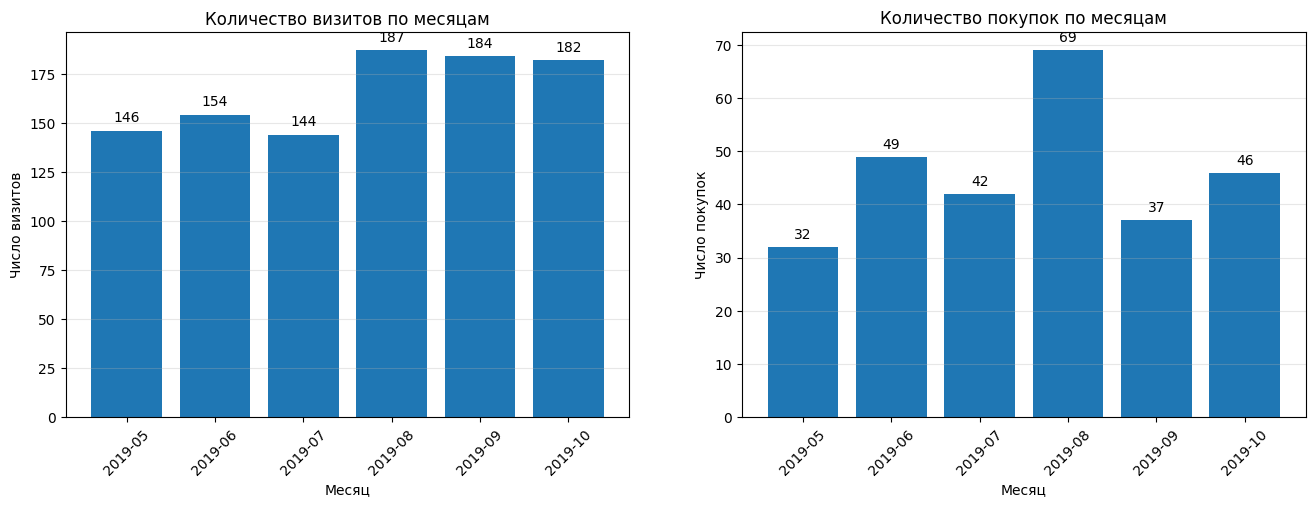

In [192]:
# определим исследуемый период исходя из количества визитов и покупок

month_visits = df.groupby(df['session_date'].dt.to_period('M')).size().sort_index()
month_sales = df.groupby(df['session_date'].dt.to_period('M'))['revenue'].count().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


bars1 = axes[0].bar(month_visits.index.astype(str), month_visits.values)  # СОХРАНИТЬ В bars1
axes[0].set_title('Количество визитов по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Число визитов')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, month_visits.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 3,
                f'{value}', ha='center', va='bottom')


bars2 = axes[1].bar(month_sales.index.astype(str), month_sales.values)  # СОХРАНИТЬ В bars2
axes[1].set_title('Количество покупок по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Число покупок')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)


for bar, value in zip(bars2, month_sales.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value}', ha='center', va='bottom')

plt.show()

Краткие выводы

Количество визитов по месяцам: \
Август - самый большой показатель (187), далее показатель стабилизировался на этом уровне (182-187).

Количество покупок по месяцам: \
Август - самый большой показатель. Резко выделяется относительно других месяцев.

Поскольку на протяжении всего периода наблюдается активность от пользователей (визиты и покупки), будем рассматривать имеющийся период целиком. (К тому же представленный период сам по себе не очень большой - всего полгода)

### Аналитический и графический анализ данных

In [193]:
# для оценки доли продаж создадим отдельный датафрейм с покупками

df_sales = df[df['payer'] == 1]

In [194]:
# функция для подсчета доли суммы продаж и их количества

def share_sales(df, factor):

    # что приносит больше денег
    df_sum = df.groupby(factor)['revenue'].sum()
    result_sum = df_sum / df_sum.sum()
    print("Сумма продаж:")
    print(result_sum.round(2), '\n')

    # что приносит больше покупателей
    df_count = df.groupby(factor)['revenue'].count()
    result_count = df_count / df_count.sum()
    print("Количество продаж:")
    print(result_count.round(2))

In [195]:
print("==========================================")
print("Доля продаж по регионам\n")
share_sales(df_sales, 'region')
print("\n==========================================")

print("Доля продаж по устройствам\n")
share_sales(df_sales, 'device')
print("\n==========================================")

print("Доля продаж по источникам\n")
share_sales(df_sales, 'channel')
print("\n==========================================")

Доля продаж по регионам

Сумма продаж:
region
France           0.17
Germany          0.07
UK               0.14
United States    0.62
Name: revenue, dtype: float64 

Количество продаж:
region
France           0.09
Germany          0.09
UK               0.12
United States    0.71
Name: revenue, dtype: float64

Доля продаж по устройствам

Сумма продаж:
device
Android    0.20
Mac        0.22
PC         0.25
iPhone     0.32
Name: revenue, dtype: float64 

Количество продаж:
device
Android    0.26
Mac        0.21
PC         0.19
iPhone     0.34
Name: revenue, dtype: float64

Доля продаж по источникам

Сумма продаж:
channel
email-рассылки         0.02
organic                0.35
контекстная реклама    0.12
реклама у блогеров     0.18
социальные сети        0.33
Name: revenue, dtype: float64 

Количество продаж:
channel
email-рассылки         0.02
organic                0.32
контекстная реклама    0.15
реклама у блогеров     0.11
социальные сети        0.40
Name: revenue, dtype: float64



In [196]:
def plot_simple_share_sales(df, factor, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_sum = df.groupby(factor)['revenue'].sum()
    result_sum = df_sum / df_sum.sum() 
    df_count = df.groupby(factor)['revenue'].count()
    result_count = df_count / df_count.sum()

    result_sum_sorted = result_sum.sort_values(ascending=False)
    result_count_sorted = result_count[result_sum_sorted.index]
    
    axes[0].bar(result_sum_sorted.index.astype(str), result_sum_sorted.values)
    axes[0].set_title(f'{title} (по сумме)')
    axes[0].set_xlabel(factor)
    axes[0].set_ylabel('Доля')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(result_sum_sorted.values):
        axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
    
    axes[1].bar(result_count_sorted.index.astype(str), result_count_sorted.values)
    axes[1].set_title(f'{title} (по количеству)')
    axes[1].set_xlabel(factor)
    axes[1].set_ylabel('Доля')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(result_count_sorted.values):
        axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return result_sum, result_count

Доля продаж по регионам



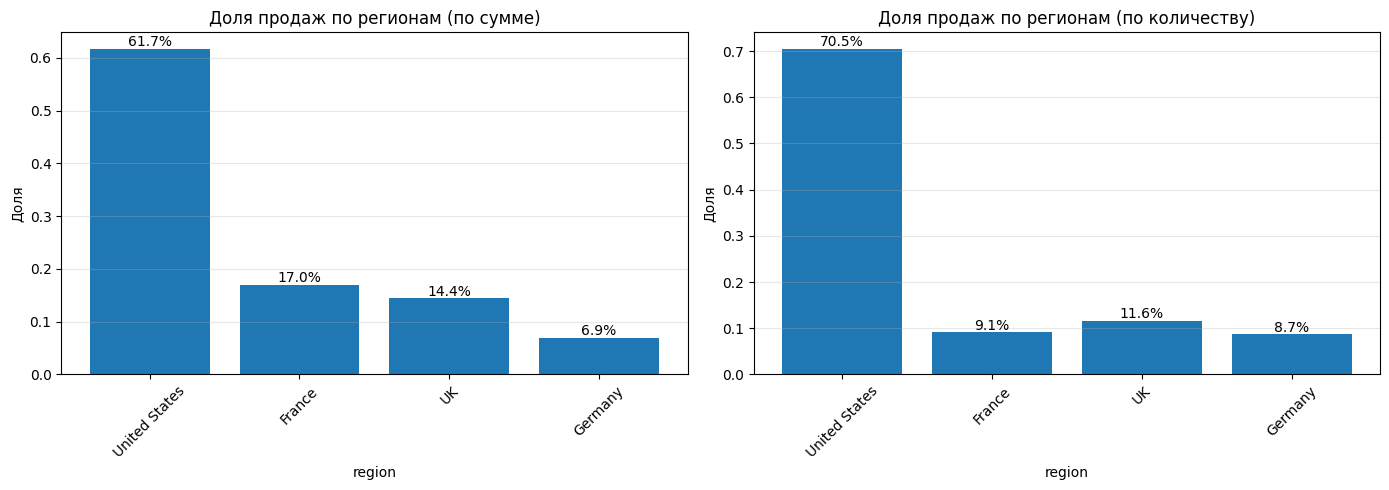


Доля продаж по устройствам



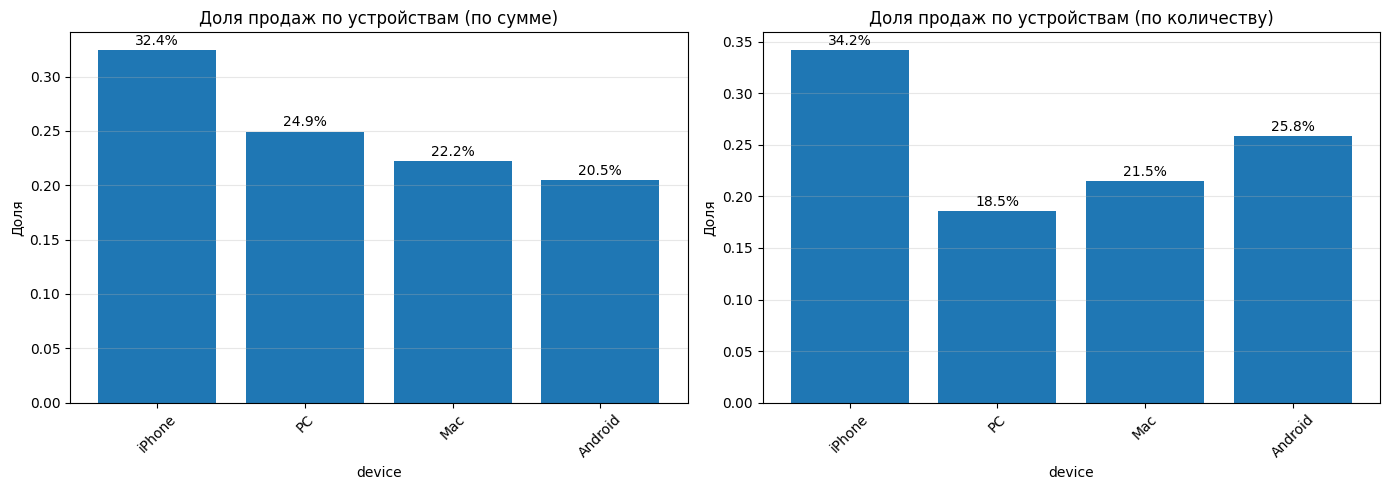


Доля продаж по источникам



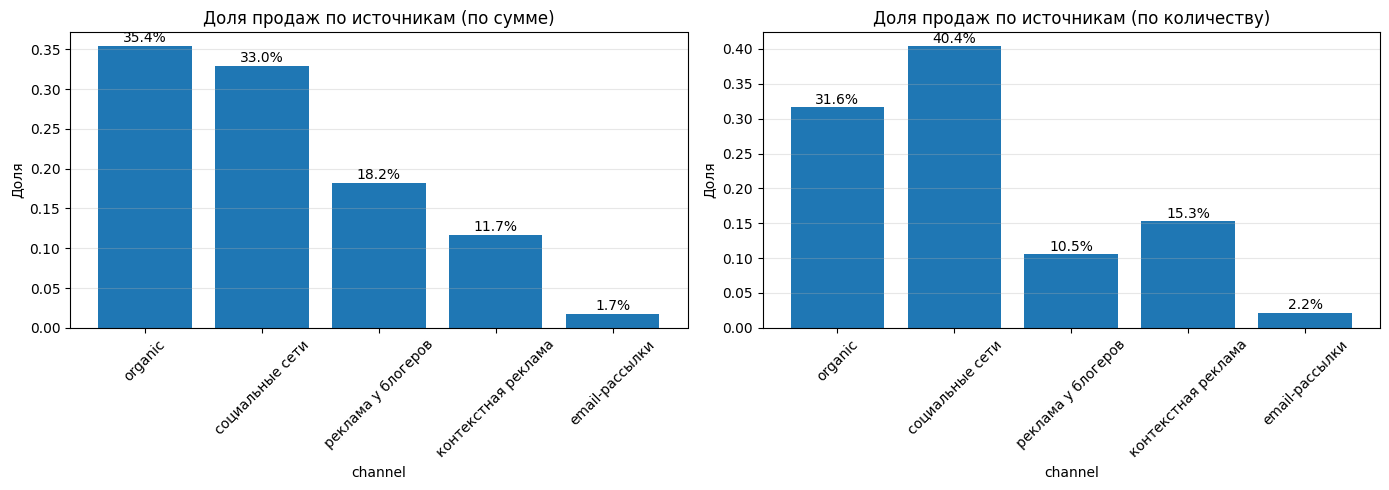

In [197]:
print("==========================================")
print("Доля продаж по регионам\n")
sum_region, count_region = plot_simple_share_sales(df_sales, 'region', 'Доля продаж по регионам')

print("\n==========================================")
print("Доля продаж по устройствам\n")
sum_device, count_device = plot_simple_share_sales(df_sales, 'device', 'Доля продаж по устройствам')

print("\n==========================================")
print("Доля продаж по источникам\n")
sum_channel, count_channel = plot_simple_share_sales(df_sales, 'channel', 'Доля продаж по источникам')
print("\n==========================================")

Краткие выводы

По регионам: \
США приносит больше всего заказов по количеству и прибыли. (резкий отрыв от других регионов) \
Германия — меньше всего заказов по количеству и прибыли. 

По устройствам: \
Айфон приносит больше всего заказов по количеству и прибыли. (Отрыв есть, но не сильно большой) 

По источникам: \
Лидеры по прибыли с заказов — organic (35,4%) и социальные сети (33%) \
Лидеры по количеству заказов — социальные сети (40,4%) и organic (31,6%) \
Email-рассылки ОЧЕНЬ низкие показатели и по количеству продаж (2,2%) и по прибыли (1,7%).

In [198]:
# функиця для подсчета количества пользователей с разбивкой на платящих/не платящих

def users_count(df, factor):
    df_result = df.groupby(['payer', factor])['user_id'].nunique()
    print(df_result)

In [199]:
print("==========================================")
print("Количество пользователей по регионам\n")
users_count(df, 'region')
print("\n==========================================")

print("Количество пользователей по устройствам\n")
users_count(df, 'device')
print("\n==========================================")

print("Количество пользователей по источникам\n")
users_count(df, 'channel')
print("\n==========================================")

Количество пользователей по регионам

payer  region       
0      France            78
       Germany           78
       UK                83
       United States    483
1      France            25
       Germany           24
       UK                32
       United States    194
Name: user_id, dtype: int64

Количество пользователей по устройствам

payer  device 
0      Android    164
       Mac        142
       PC         155
       iPhone     261
1      Android     71
       Mac         59
       PC          51
       iPhone      94
Name: user_id, dtype: int64

Количество пользователей по источникам

payer  channel            
0      email-рассылки          17
       organic                259
       контекстная реклама    117
       реклама у блогеров      71
       социальные сети        258
1      email-рассылки           6
       organic                 87
       контекстная реклама     42
       реклама у блогеров      29
       социальные сети        111
Name: user_id, dtype

In [200]:
def plot_users_count(df, factor, title):
    df_result = df.groupby(['payer', factor])['user_id'].nunique().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 5)) 
    x = np.arange(len(df_result.columns))
    width = 0.35
    ax.bar(x - width/2, df_result.loc[0], width, label='Не платящие', alpha=0.8)
    ax.bar(x + width/2, df_result.loc[1], width, label='Платящие', color='darkblue', alpha=0.8) 
    ax.set_title(f'{title}')
    ax.set_xlabel(factor)
    ax.set_ylabel('Количество пользователей')
    ax.set_xticks(x)
    ax.set_xticklabels(df_result.columns, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(df_result.loc[0]):
        ax.text(i - width/2, v + 5, str(int(v)), ha='center', fontsize=10)
    for i, v in enumerate(df_result.loc[1]):
        ax.text(i + width/2, v + 5, str(int(v)), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return df_result

Количество пользователей по регионам



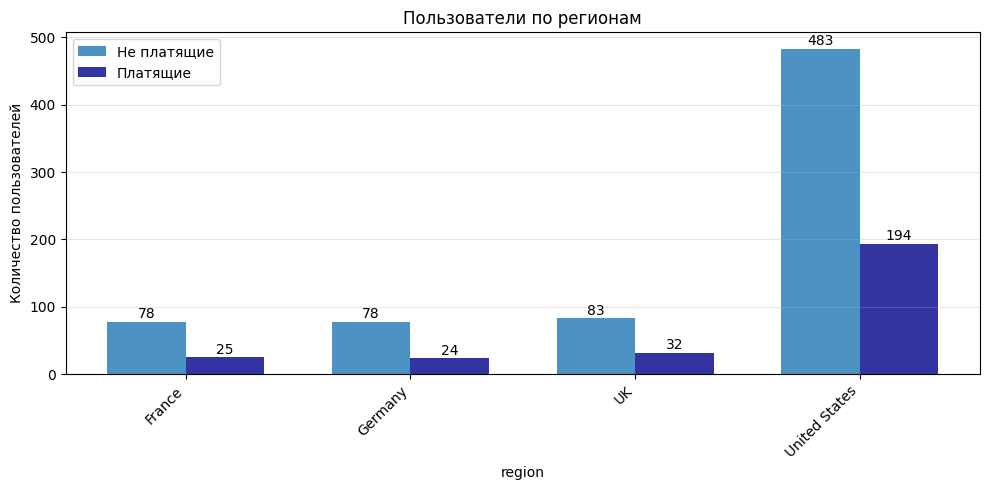


Количество пользователей по устройствам



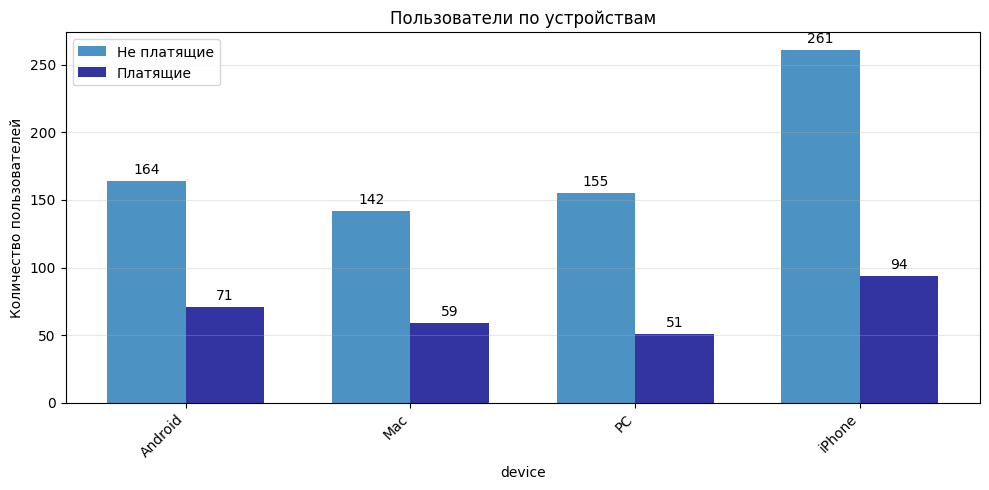


Количество пользователей по источникам



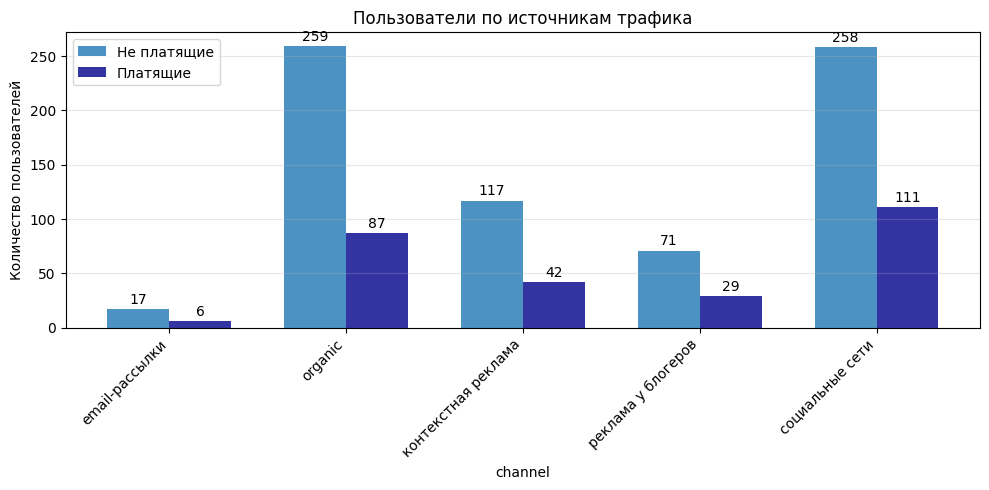

In [201]:
print("==========================================")
print("Количество пользователей по регионам\n")
users_region = plot_users_count(df, 'region', 'Пользователи по регионам')

print("\n==========================================")
print("Количество пользователей по устройствам\n")
users_device = plot_users_count(df, 'device', 'Пользователи по устройствам')

print("\n==========================================")
print("Количество пользователей по источникам\n")
users_channel = plot_users_count(df, 'channel', 'Пользователи по источникам трафика')
print("\n==========================================")

Краткие выводы:

По регионам: \
Больше всего пользователей в США (платящих и не платящих). (резкий отрыв)

По устройствам: \
Больше всего пользователей с iPhone (платящих и не платящих). (Отрыв есть, но не очень большой. В целом по устройствам результаты равномерные)

По источникам: \
Больше всего пользователей от социальных сетей и organic (платящих и не платящих). (резкий отрыв) \
Email-рассылки — ОЧЕНЬ низкие показатели.

In [202]:
# Графики, показывающие есть ли сезонность в продажах по месяцам, дням недели, времени суток (количество продаж и суммарная прибыль)

def sales_plot_double(df, factor, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    revenue_sum = df.groupby(factor)['revenue'].sum()
    
    if factor == 'day_time':
        order = ['утро', 'день', 'вечер', 'ночь']
        revenue_sum = revenue_sum.reindex(order)
        axes[0].plot(range(len(revenue_sum)), revenue_sum.values, marker='o', linewidth=2)
        axes[0].set_xticks(range(len(order)))
        axes[0].set_xticklabels(order)
    elif factor == 'month':
        axes[0].plot(revenue_sum.index, revenue_sum.values, marker='o', linewidth=2)
        axes[0].set_xticks(revenue_sum.index)
    else:
        axes[0].plot(range(len(revenue_sum)), revenue_sum.values, marker='o', linewidth=2)
        axes[0].set_xticks(range(len(revenue_sum)))
        axes[0].set_xticklabels(revenue_sum.index.astype(str))
    
    axes[0].set_title(f'{title_prefix} (сумма продаж)')
    axes[0].set_xlabel(factor)
    axes[0].set_ylabel('Сумма продаж')
    axes[0].grid(axis='y', alpha=0.3)
    

    sales_count = df.groupby(factor)['revenue'].count()
    if factor == 'day_time':
        order = ['утро', 'день', 'вечер', 'ночь']
        sales_count = sales_count.reindex(order)
        axes[1].plot(range(len(sales_count)), sales_count.values, marker='o', linewidth=2)
        axes[1].set_xticks(range(len(order)))
        axes[1].set_xticklabels(order)
    elif factor == 'month':
        axes[1].plot(sales_count.index, sales_count.values, marker='o', linewidth=2)
        axes[1].set_xticks(sales_count.index)
    else:
        axes[1].plot(range(len(sales_count)), sales_count.values, marker='o', linewidth=2)
        axes[1].set_xticks(range(len(sales_count)))
        axes[1].set_xticklabels(sales_count.index.astype(str))
    
    axes[1].set_title(f'{title_prefix} (количество продаж)')
    axes[1].set_xlabel(factor)
    axes[1].set_ylabel('Количество продаж')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return revenue_sum, sales_count

Сезонность по месяцам



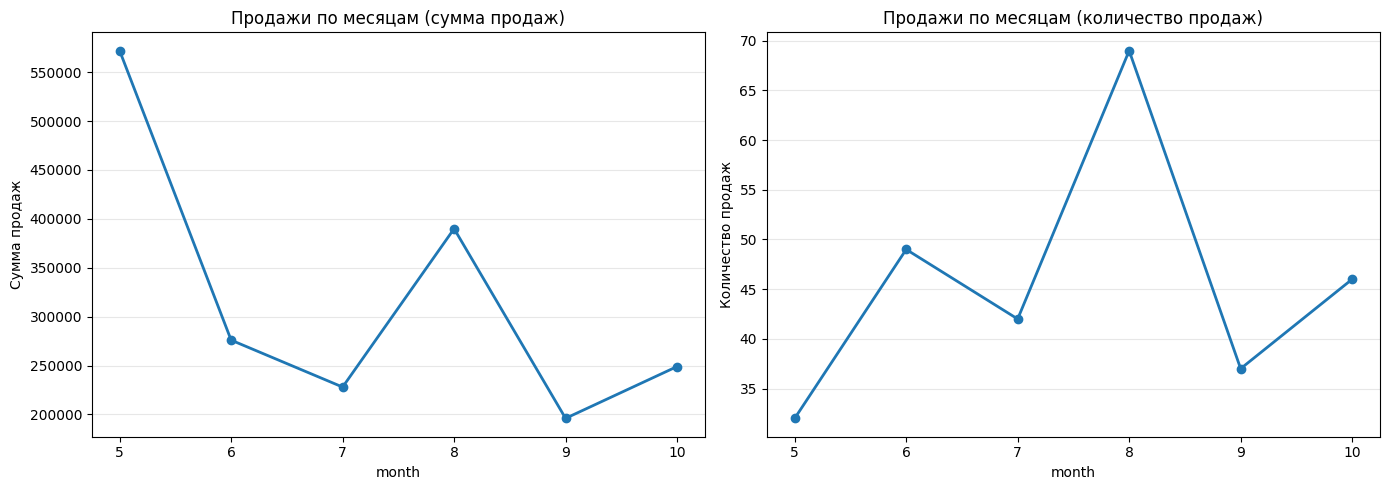


Сезонность по дням недели



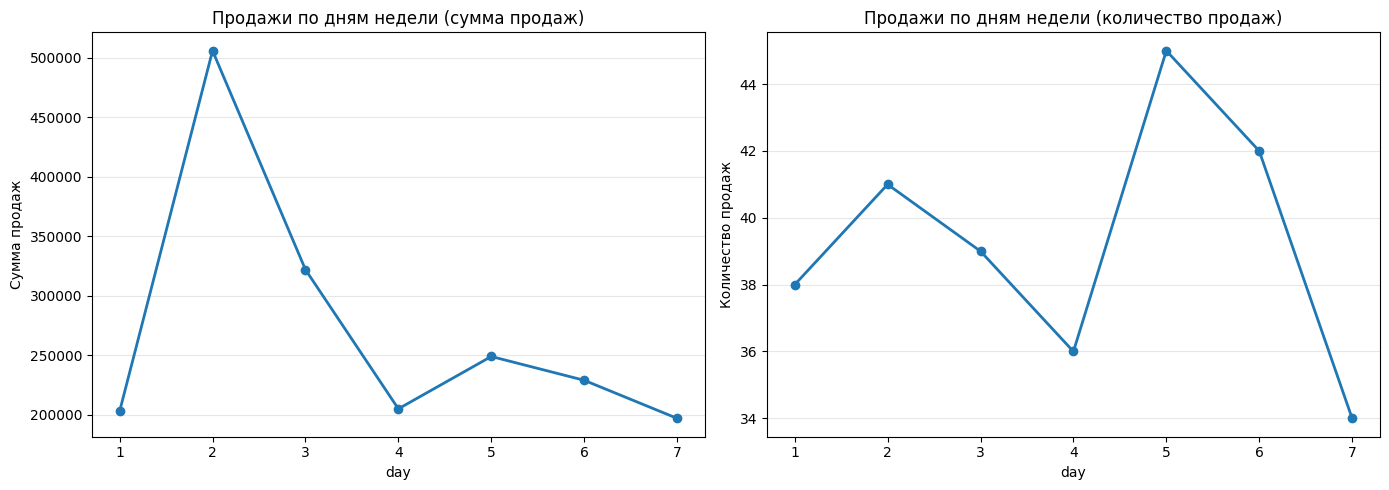


Сезонность по времени суток



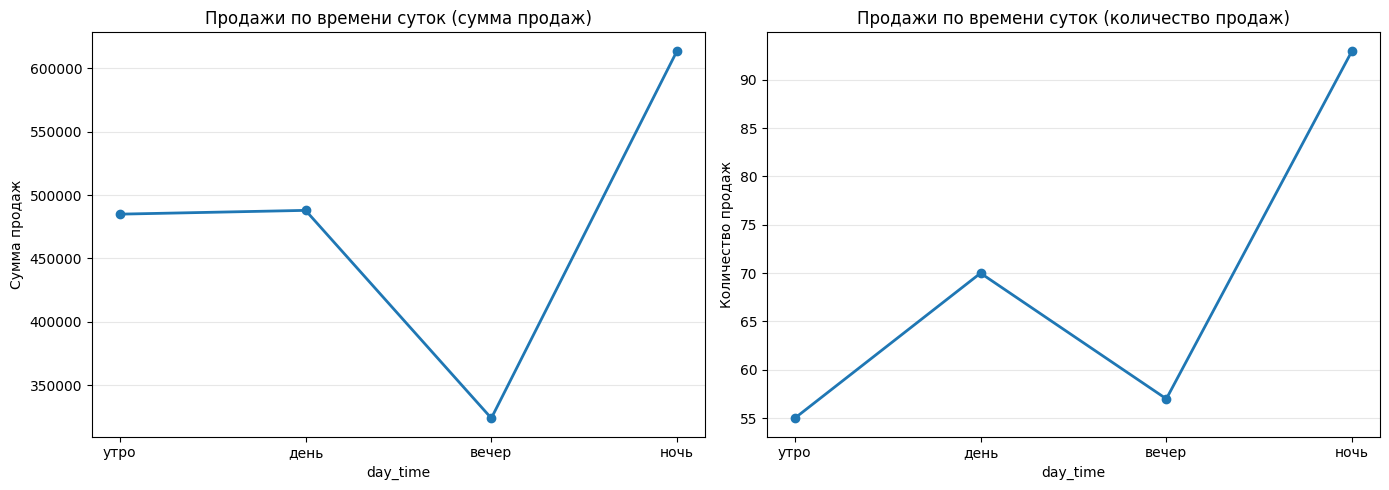

In [203]:
# Использование функции без вывода данных:
print("==========================================")
print("Сезонность по месяцам\n")
month_revenue, month_count = sales_plot_double(df_sales, 'month', 'Продажи по месяцам')

print("\n==========================================")
print("Сезонность по дням недели\n")
day_revenue, day_count = sales_plot_double(df_sales, 'day', 'Продажи по дням недели')

print("\n==========================================")
print("Сезонность по времени суток\n")
time_revenue, time_count = sales_plot_double(df_sales, 'day_time', 'Продажи по времени суток')
print("\n==========================================")

Краткие выводы

По месяцам: \
Самый прибыльный месяц — май. Второе место — август. (Как будто в целом есть спад) \
Больше всего покупок — август. Меньше всего — май (видимо были очень крупные покупки).

Дни недели: \
Больше всего тратят (сумма) во вторник. Больше всего покупают (количество) в пятницу и вторник.

По времени суток: \
Больше всего тратят и покупают ночью.

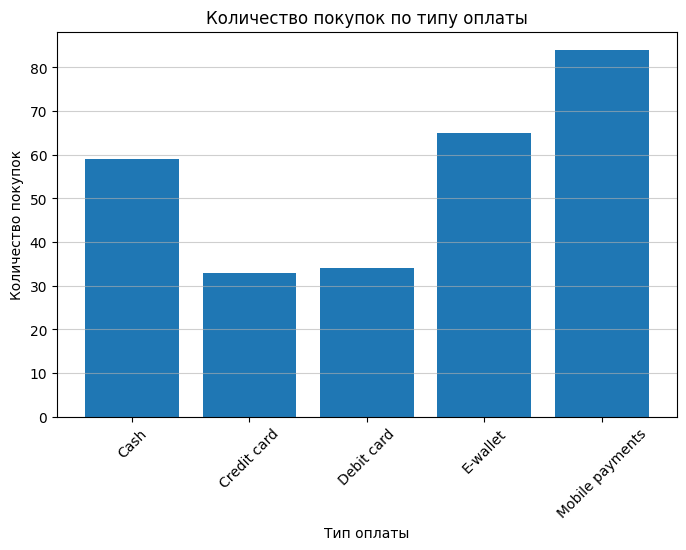

In [204]:
# диаграмма количества покупок по типу оплаты

df_payment_type_sales = df_sales.groupby('payment_type')['revenue'].count()
plt.figure(figsize=(8, 5))
plt.bar(df_payment_type_sales.index, df_payment_type_sales.values)
plt.title('Количество покупок по типу оплаты')
plt.xlabel('Тип оплаты')
plt.ylabel('Количество покупок')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.6)
plt.show()

Выводы по предобработке и исследованию данных

1. Качество исходных данных и очистка
   
В данных присутствовали пропуски (1.3% строк) и явные дубликаты (0.2% строк), которые были исключены из анализа. \
Обнаружены и исправлены неявные дубликаты в категориальных признаках (Region, Device, Channel), связанные с некорректным кодированием символов. \
Выявлены и скорректированы аномалии в числовых данных: экстремально низкая выручка (1 рубль) и некорректные значения в бинарном поле promo_code. 

2. Временной охват и динамика активности

Исследуемый период — с мая по октябрь 2019 года (6 месяцев). 

3. Ключевые наблюдения:

Трафик стабильно рос с мая по август. \
Август стал рекордным месяцем с 187 визитами, что на 28% больше, чем в стартовом мае (146 визитов). \
После августовского пика трафик стабилизировался на высоком уровне (184-182 визита в сентябре-октябре). \
Покупки показали максимальную эффективность в августе:69 покупок в августе — это более чем в 2 раза выше, чем в мае (32 покупки). \
Несмотря на почти неизменный трафик (184 визита), покупки в сентябре упали на 46% по сравнению с августом (с 69 до 37).

# Проведение расчётов

In [205]:
# Средний чек БЕЗ ВЫБРОСОВ

normal_sales = df_sales[df_sales['revenue'] < 10000]
mean_revenue = normal_sales['revenue'].mean()
print("Средний чек:", mean_revenue.round(0))

Средний чек: 5575.0


In [206]:
# Средний чек

mean_revenue = df_sales['revenue'].mean()
print("Средний чек:", mean_revenue.round(0))

Средний чек: 6948.0


In [207]:
# Сколько покупок в среднем совершает 1 пользователь?

df_users_sales = df_sales.groupby('user_id')['revenue'].count().mean()
print("Покупок на одного человека:", df_users_sales)

Покупок на одного человека: 1.0


In [208]:
# Рассчитать среднюю продолжительность сессии по рекламным каналам.

# Нет ли никакой проблемы, что у нас нужно уникализировать пользователей??
mean_session_by_channel_min = df.groupby('channel').agg(
    {'sessiondurationsec':'mean'}).rename(columns={'sessiondurationsec':'mean_sess_dur_minutes'})
mean_session_by_channel_min['mean_sess_dur_minutes'] = (mean_session_by_channel_min['mean_sess_dur_minutes'] / 60).round(2)
print(mean_session_by_channel_min)

                     mean_sess_dur_minutes
channel                                   
email-рассылки                       31.99
organic                              31.17
контекстная реклама                  32.70
реклама у блогеров                   30.88
социальные сети                      28.19


Средняя продолжительность сессии по рекламным каналам особо не отличается, варьируетсяот 28 до 32 минут

In [209]:
# Рассчитать среднюю продолжительность сессии по типу устройства.
mean_sess_by_device_min = df.groupby('device').agg(
    {'sessiondurationsec':'mean'}).rename(columns={'sessiondurationsec':'mean_sess_dur_minutes'})
mean_sess_by_device_min['mean_sess_dur_minutes'] = (mean_sess_by_device_min['mean_sess_dur_minutes'] / 60).round(2)
print(mean_sess_by_device_min)

         mean_sess_dur_minutes
device                        
Android                  31.68
Mac                      29.48
PC                       32.33
iPhone                   28.68


Средняя продолжительность сессии по типу устройства особо не отличается, варьируетсяот 28 до 32 минут

In [210]:
# Определить топ-3 рекламных канала по среднему чеку.

mean_revenue_by_channel = df_sales.groupby('channel').agg({'final_revenue':'mean'}).rename(
    columns={'final_revenue':'mean_revenue'}).sort_values(by='mean_revenue', ascending=False).round(2)
print(mean_revenue_by_channel)

                     mean_revenue
channel                          
реклама у блогеров       11999.07
organic                   7769.14
социальные сети           5674.68
email-рассылки            5499.00
контекстная реклама       5332.33


топ 3 рекламных канала по среднему чеку: реклама у блогеров, organic, социальные сети

In [211]:
# Определить топ-3 региона по среднему чеку.
mean_revenue_by_region = df_sales.groupby('region').agg({'final_revenue':'mean'}).rename(
    columns={'final_revenue':'mean_revenue'}).sort_values(by='mean_revenue', ascending=False).round(2)
print(mean_revenue_by_region)

               mean_revenue
region                     
France             12959.08
UK                  8592.78
United States       6081.48
Germany             5499.00


топ 3 региона по среднему чеку: франция, великобритания, сша

In [212]:
# Определить топ-3 месяца по среднему чеку с разбивкой по регионам.
mean_revenue_by_month_region = df_sales.groupby(['month', 'region']).agg({'final_revenue':'mean'}).rename(
    columns={'final_revenue':'mean_revenue'}).round(2)
mean_revenue_by_month_region = mean_revenue_by_month_region.groupby(level=0, group_keys=False).apply(
    lambda x: x.sort_values('mean_revenue', ascending=False))
print(mean_revenue_by_month_region)

sum_mean_revenue_by_month = mean_revenue_by_month_region.reset_index().groupby('month').agg({'mean_revenue':'sum'}).rename(
    columns={'mean_revenue':'sum_mean_revenue'}).sort_values(by='sum_mean_revenue', ascending=False)
print(sum_mean_revenue_by_month)

                     mean_revenue
month region                     
5     France             52999.50
      UK                 52999.50
      United States      10390.35
      Germany             4999.00
6     Germany             5799.00
      United States       5665.67
      France              5570.43
      UK                  5427.57
7     Germany             7499.00
      United States       5351.94
      UK                  5199.00
      France              4999.00
8     UK                  5776.78
      United States       5743.68
      France              5249.00
      Germany             5221.22
9     United States       5356.14
      Germany             5249.00
      France              4999.00
      UK                  4999.00
10    UK                  6141.86
      France              5332.33
      United States       5280.25
      Germany             4999.00
       sum_mean_revenue
month                  
5             121388.35
7              23048.94
6              22462

В первой таблице получили средний чек в каждом регионе в определенном месяце.
Во второй таблице сложили суммы средних чеков в каждом регионе за конкретные месяцы, получив, таким образом, средний чек за месяц.
Топ 3 месяца: 5(май), 7(июль), 6(июнь)

In [213]:
# Посчитать MAU* по каждому месяцу с разбивкой по рекламным каналам и выделить топ-3 рекламных каналов по количеству уникальных пользователей в месяц.
# *MAU (Monthly Active Users) — это количество уникальных пользователей за месяц.
MAU_by_channel = df.groupby(['month', 'channel']).agg({'user_id':'nunique'}).rename(columns={'user_id':'MAU'})
MAU_by_channel = MAU_by_channel.groupby(level=0, group_keys=False).apply(lambda x: x.sort_values('MAU', ascending=False))
print(MAU_by_channel)

MAU_by_channel = MAU_by_channel.reset_index().groupby('month').agg({'MAU':'sum'}).rename(
    columns={'MAU':'sum_MAU'}).sort_values(by='sum_MAU', ascending=False)
print(MAU_by_channel)

                           MAU
month channel                 
5     organic               76
      социальные сети       41
      реклама у блогеров    14
      контекстная реклама    8
      email-рассылки         7
6     organic               59
      социальные сети       53
      контекстная реклама   28
      реклама у блогеров    13
      email-рассылки         1
7     социальные сети       56
      organic               46
      контекстная реклама   24
      реклама у блогеров    15
      email-рассылки         3
8     социальные сети       68
      organic               60
      контекстная реклама   35
      реклама у блогеров    20
      email-рассылки         4
9     социальные сети       66
      organic               58
      контекстная реклама   38
      реклама у блогеров    20
      email-рассылки         2
10    социальные сети       85
      organic               47
      контекстная реклама   26
      реклама у блогеров    18
      email-рассылки         6
       s

Большее количество уникальных пользователей за месяц было в августе, сентябре и октябре.  \
В каждом из этих месяцев топ-3 рекламных канала: соц. сети, organic, контекстная реклама.

In [214]:
# Составить таблицу в которой будет указано по рекламным каналам: 
# количество пользователей, 
# количество уникальных пользователей, 
# количество платящих пользователей, 
# сумма продаж
# и определить какой источник “принес” больше всего платящих пользователей и большую сумму продаж.
users_descr_by_channel_1 = df.groupby('channel').agg(cnt_users=('user_id', 'count'), sum_revenue=('final_revenue', 'sum')).reset_index()
unique_users = df.drop_duplicates(subset=['user_id'], keep=False)
users_descr_by_channel_2 = unique_users.groupby('channel').agg(cnt_unique_users=('user_id', 'nunique'), cnt_payers=('payer', 'sum')).reset_index()
users_descr = pd.merge(users_descr_by_channel_1, users_descr_by_channel_2, on='channel', how='inner')
users_descr = users_descr.set_index(['channel']).sort_values(by='sum_revenue', ascending=False)
print(users_descr)

                     cnt_users  sum_revenue  cnt_unique_users  cnt_payers
channel                                                                  
organic                    346     675915.0               346          87
социальные сети            369     629889.0               369         111
реклама у блогеров         100     347973.0               100          29
контекстная реклама        159     223958.0               159          42
email-рассылки              23      32994.0                23           6


Больше всего платящих пользователей принесли социальные сети.
БОльшую сумму продаж получили от органических пользователей (organic channel)

1) Самый прибыльный месяц был май, далее спад.  
2) Наивысший средний чек во Франции.  
3) реклама у блогеров приносит высокий средний чек, однако охватывает малую часть пользователей.
4)  Соцсети и organic трафики лидируют по количеству активных пользователей ежемесячно, также лидируют по суммарным продажам

# Проверка гипотез

#### Влияет ли тип устройства на количество покупок в день по каждому региону?

H0 - тип устройства не влияет на количество покупок в день по каждому региону  \
H1 - тип устройства влияет на количество покупок в день по каждому региону  \
фактор - устройства (категориальная величина), отклик - количество покупок в день (количесвтенная)  \
количесвто уровней в категориальной шкале: 4

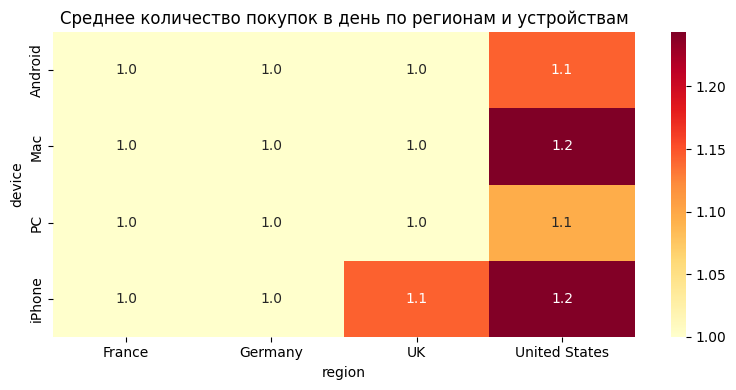

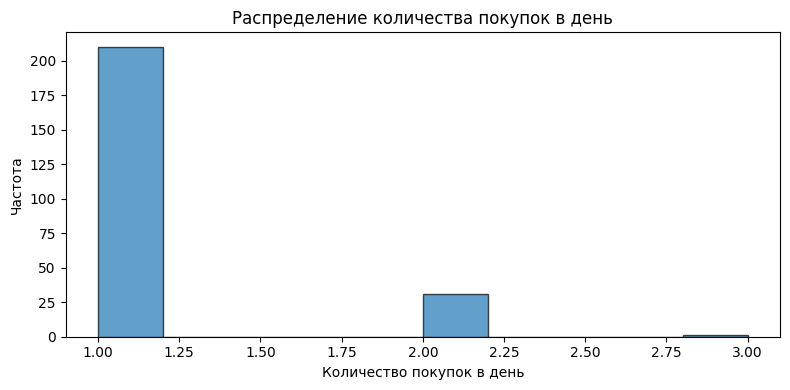

France: Все значения одинаковы (1)
Germany: Все значения одинаковы (1)
UK: p=0.3301 Верна нулевая гипотеза: тип устройства не влияет на количество покупок в день
United States: p=0.3858 Верна нулевая гипотеза: тип устройства не влияет на количество покупок в день


In [215]:


daily = df_sales.groupby(['region', 'device', 'session_date']).size().reset_index(name='purchases')
daily['purchases'] = daily['purchases'].astype('int')
pivot = daily.groupby(['device', 'region'])['purchases'].mean().unstack()
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Среднее количество покупок в день по регионам и устройствам')
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(1, figsize=(8, 4))

ax1.hist(daily['purchases'], bins=10, edgecolor='black', alpha=0.7)
ax1.set_title('Распределение количества покупок в день')
ax1.set_xlabel('Количество покупок в день')
ax1.set_ylabel('Частота')
plt.tight_layout()
plt.show()

# по гистограмме видим, что распредление ненормальное, поэтому используем критерий Краскела-Уоллиса
for region in daily['region'].unique():
    region_data = daily[daily['region'] == region]
    groups = [g['purchases'].values for _, g in region_data.groupby('device')]
    
    if len(groups) < 2:
        print(f"{region}: Только {len(groups)} группа устройств")
        continue

    all_vals = np.concatenate(groups)
    if np.unique(all_vals).size < 2:
        print(f"{region}: Все значения одинаковы ({all_vals[0]})")
        continue

    _, p = stats.kruskal(*groups)
    print(f"{region}: p={p:.4f} {'Верна альтернативная гипотеза: тип устройства влияет на количество покупок в день' if p < 0.05
        else 'Верна нулевая гипотеза: тип устройства не влияет на количество покупок в день'}")

В каждом регионе верна нулевая гипотеза: тип устройства не влияет на количество покупок в день

#### Влияет ли тип рекламного канала на количество покупок в день по каждому региону?


H0 - тип рекламного канала не влияет на количество покупок в день по каждому региону  \
H1 - тип рекламного канала влияет на количество покупок в день по каждому региону  \
фактор - рекламный канал (категориальная), отклик - количество покупок в день (количесвтенная)  \
количесвто уровней в категориальной шкале: 4

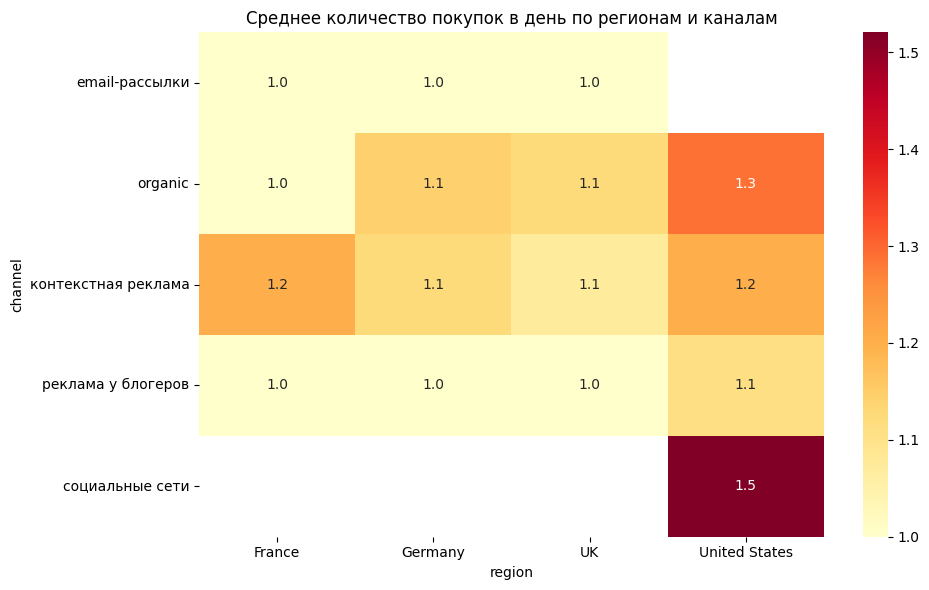

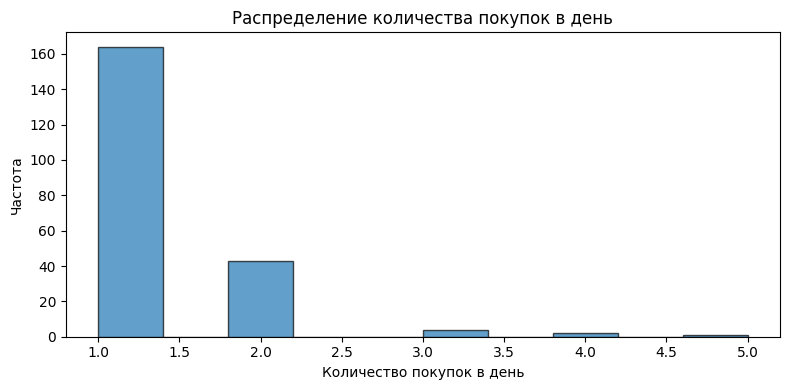

France: p=0.4362 Верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день
Germany: p=0.8028 Верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день
UK: p=0.8060 Верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день
United States: p=0.1190 Верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день


In [216]:


daily = df_sales.groupby(['region', 'channel', 'session_date']).size().reset_index(name='purchases')
pivot = daily.groupby(['channel', 'region'])['purchases'].mean().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Среднее количество покупок в день по регионам и каналам')
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(1, figsize=(8, 4))

ax1.hist(daily['purchases'], bins=10, edgecolor='black', alpha=0.7)
ax1.set_title('Распределение количества покупок в день')
ax1.set_xlabel('Количество покупок в день')
ax1.set_ylabel('Частота')
plt.tight_layout()
plt.show()

for region in daily['region'].unique():
    region_data = daily[daily['region'] == region]
    groups = [g['purchases'].values for _, g in region_data.groupby('channel')]
    
    if len(groups) > 1:
        _, p = stats.kruskal(*groups)
        print(f"{region}: p={p:.4f} {'Верна альтернативная гипотеза: тип рекламного канала влияет на количество покупок в день' if p < 0.05
        else 'Верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день'}")

В каждом регионе верна нулевая гипотеза: тип рекламного канала не влияет на количество покупок в день

#### Проверить гипотезу о том, что средний чек отличается в зависимости от региона 

H0 - средний чек не отличается в зависимости от региона  \
H1 - средний чек отличается в зависимости от региона  \
фактор - регион (категориальная), отклик (количесвтенная) - средний чек (весь доход срегиона на кол-во покупок в нем)  \

так как шкалы фактора и отклика различаются, нужно определить нормальность распределения данных в группах

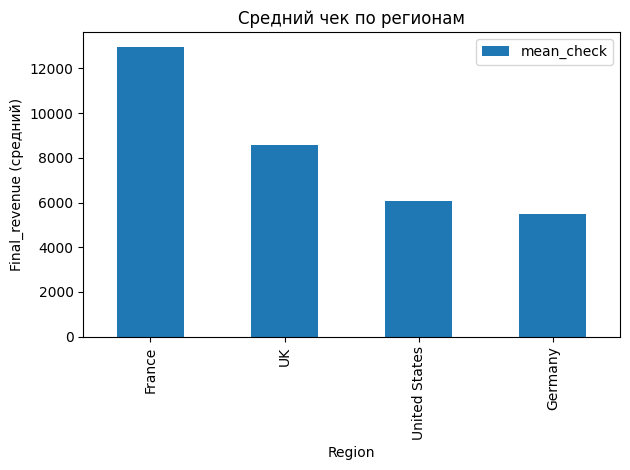

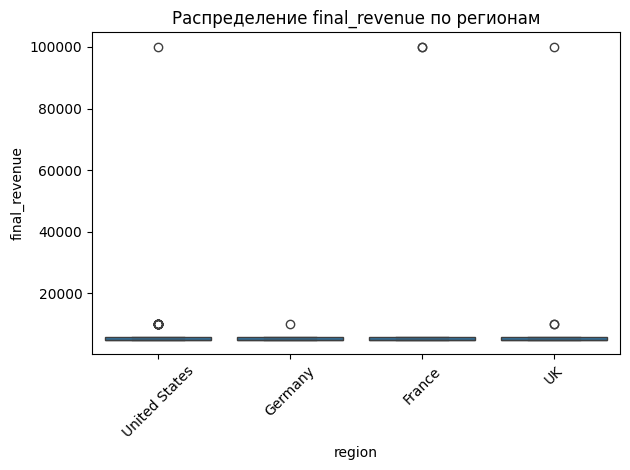

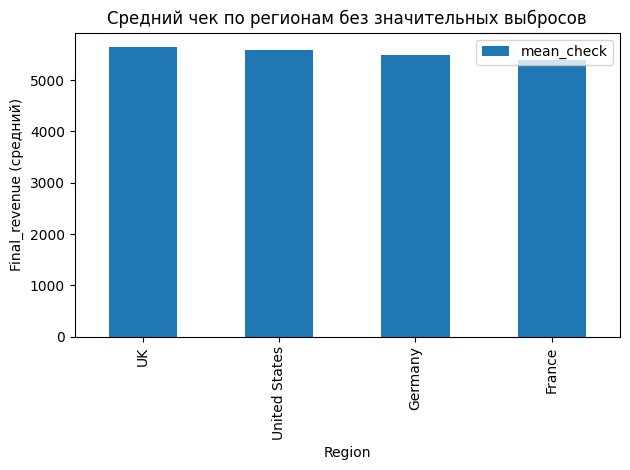

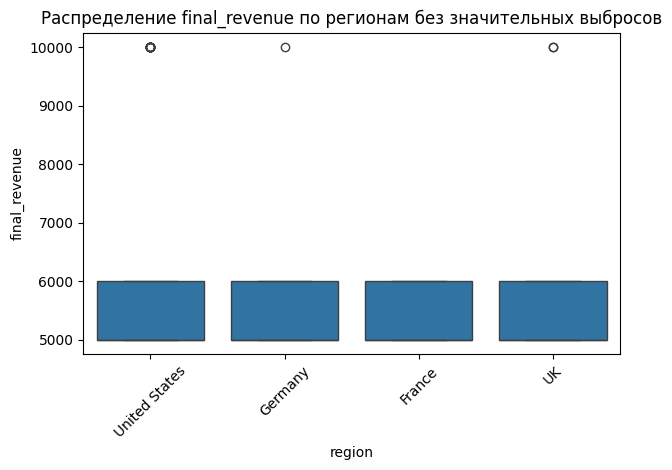

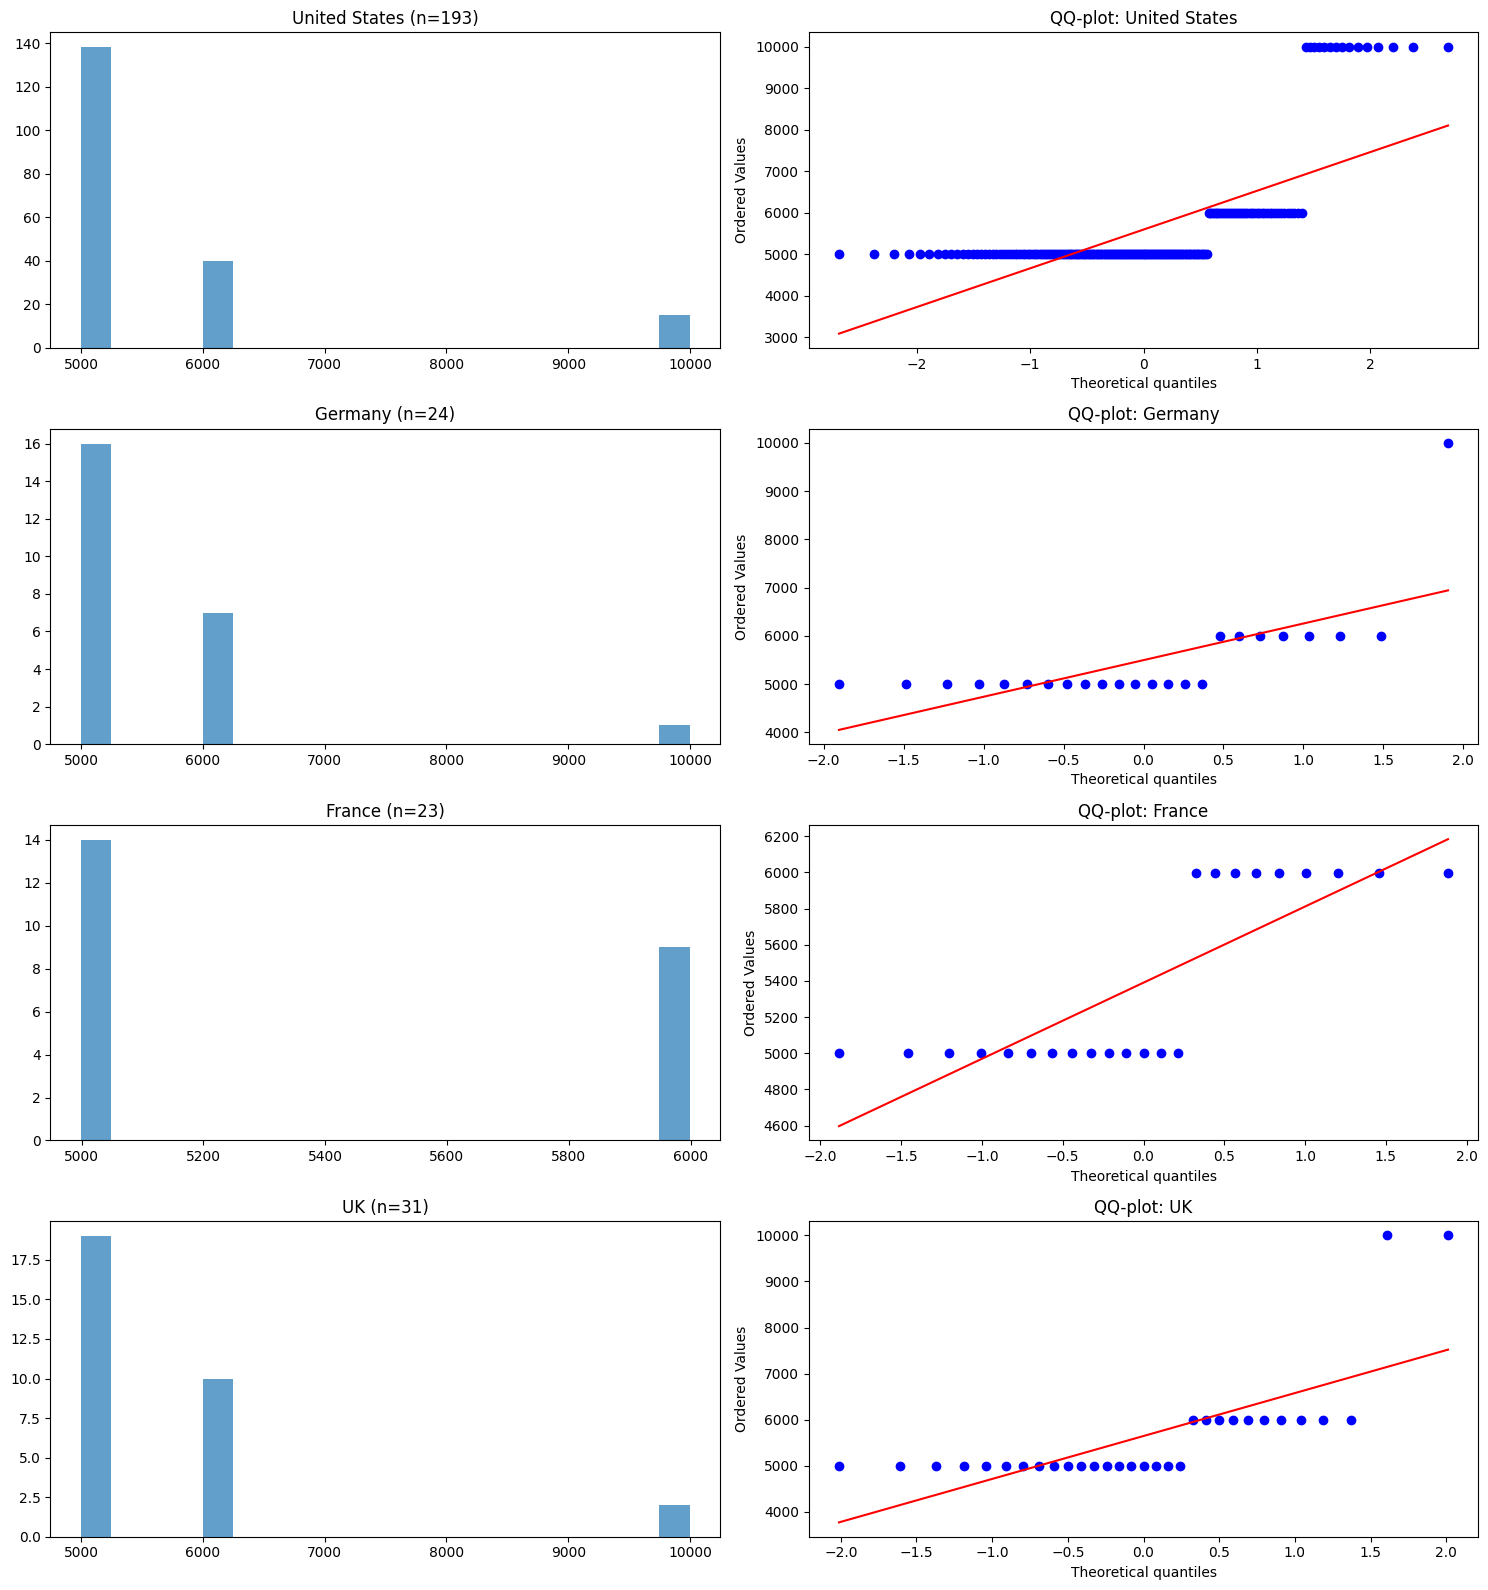

p_value: 0.7037584398131069
Не отвергаем H0, нет значимых различий между средними чеками


In [217]:

region_and_mean_check = df_sales.groupby('region').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

region_and_mean_check.plot(kind='bar')
plt.title('Средний чек по регионам')
plt.xlabel('Region')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='region', y='final_revenue', data=df_sales)
plt.title('Распределение final_revenue по регионам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# по графикам видим, что есть выбросы. исключим самые больше из них
without_emissions = df_sales[df_sales['final_revenue'] <= 10000]

region_and_mean_check = without_emissions.groupby('region').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

region_and_mean_check.plot(kind='bar')
plt.title('Средний чек по регионам без значительных выбросов')
plt.xlabel('Region')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='region', y='final_revenue', data=without_emissions)
plt.title('Распределение final_revenue по регионам без значительных выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def simple_plot_groups(df, group_col, value_col):
    groups = df[group_col].unique()
    fig, axes = plt.subplots(len(groups), 2, figsize=(15, 4*len(groups)))
    
    for i, group in enumerate(groups):
        data = df[df[group_col] == group][value_col]
        
        axes[i, 0].hist(data, bins=20, alpha=0.7)
        axes[i, 0].set_title(f'{group} (n={len(data)})')
        
        stats.probplot(data, dist="norm", plot=axes[i, 1])
        axes[i, 1].set_title(f'QQ-plot: {group}')
    
    plt.tight_layout()
    plt.show()

simple_plot_groups(without_emissions, 'region', 'final_revenue')

# благодаря графическому анализу видим, что данные распределены ненормально.

# количество уровней в категориальной шкале: 4 
# поэтому выбрали критерий Краскела-Уоллеса

regions_data = without_emissions.groupby('region')['final_revenue'].apply(list).tolist()
_, p_value = stats.kruskal(*regions_data)
print("p_value:", p_value)
if p_value < 0.05:
    print("Отвергаем H0, средний чек отличается в зависимости от региона")
else:
    print("Не отвергаем H0, нет значимых различий между средними чеками")

Исключив самые значительные из выбросов, можем заметить, что ни тест, ни графики не выявляют статистически значимых различий. Соотвественно альтернативная гипотеза не подтверждена: средний чек не отличается в зависимости от региона. 

#### Проверить гипотезу о том, что средний чек отличается в зависимости от рекламного канала?

H0 - средний чек не отличается в зависимости от рекламного канала  \
H1 - средний чек отличается в зависимости от рекламного канала  \
фактор - рекламный канал (категориальная), отклик (количесвтенная) - средний чек (весь доход с канала на кол-во покупок в нем)  \

так как шкалы фактора и отклика различаются, нужно определить нормальность распределения данных в группах

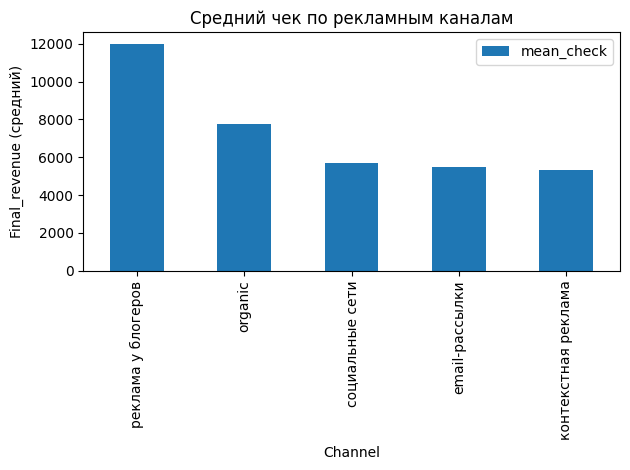

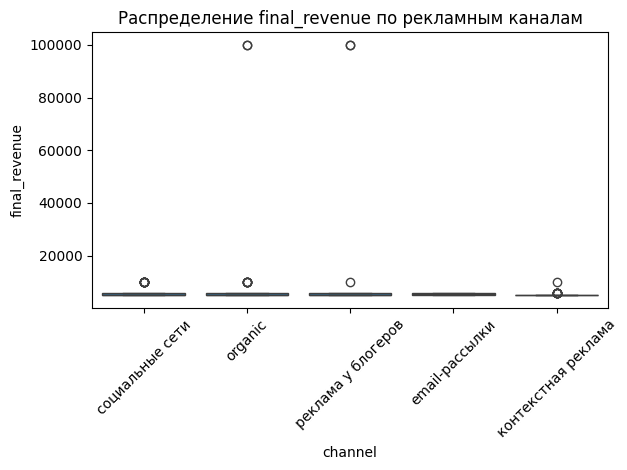

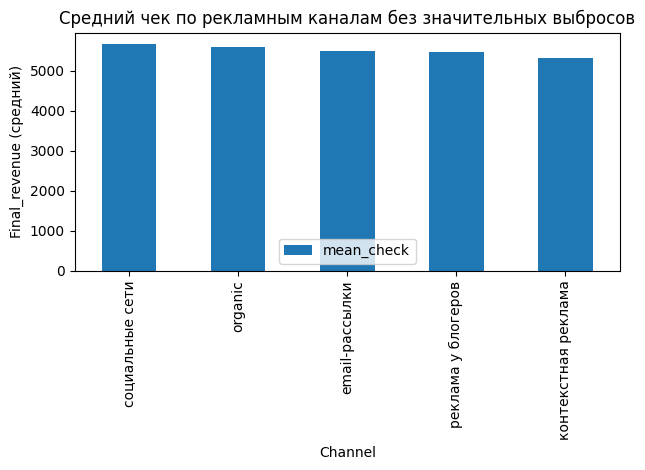

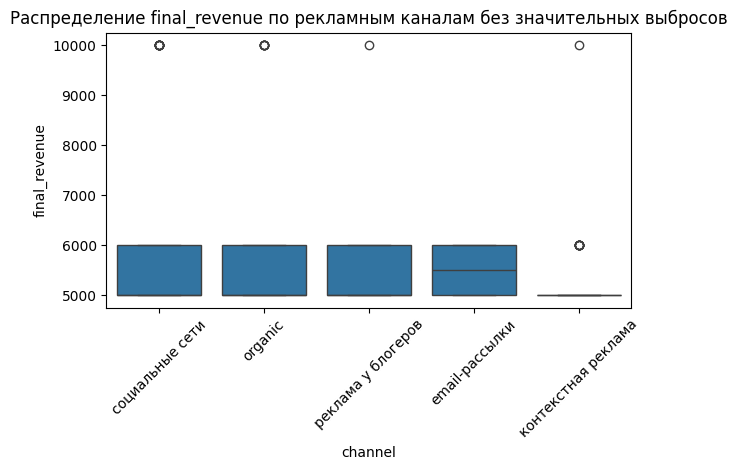

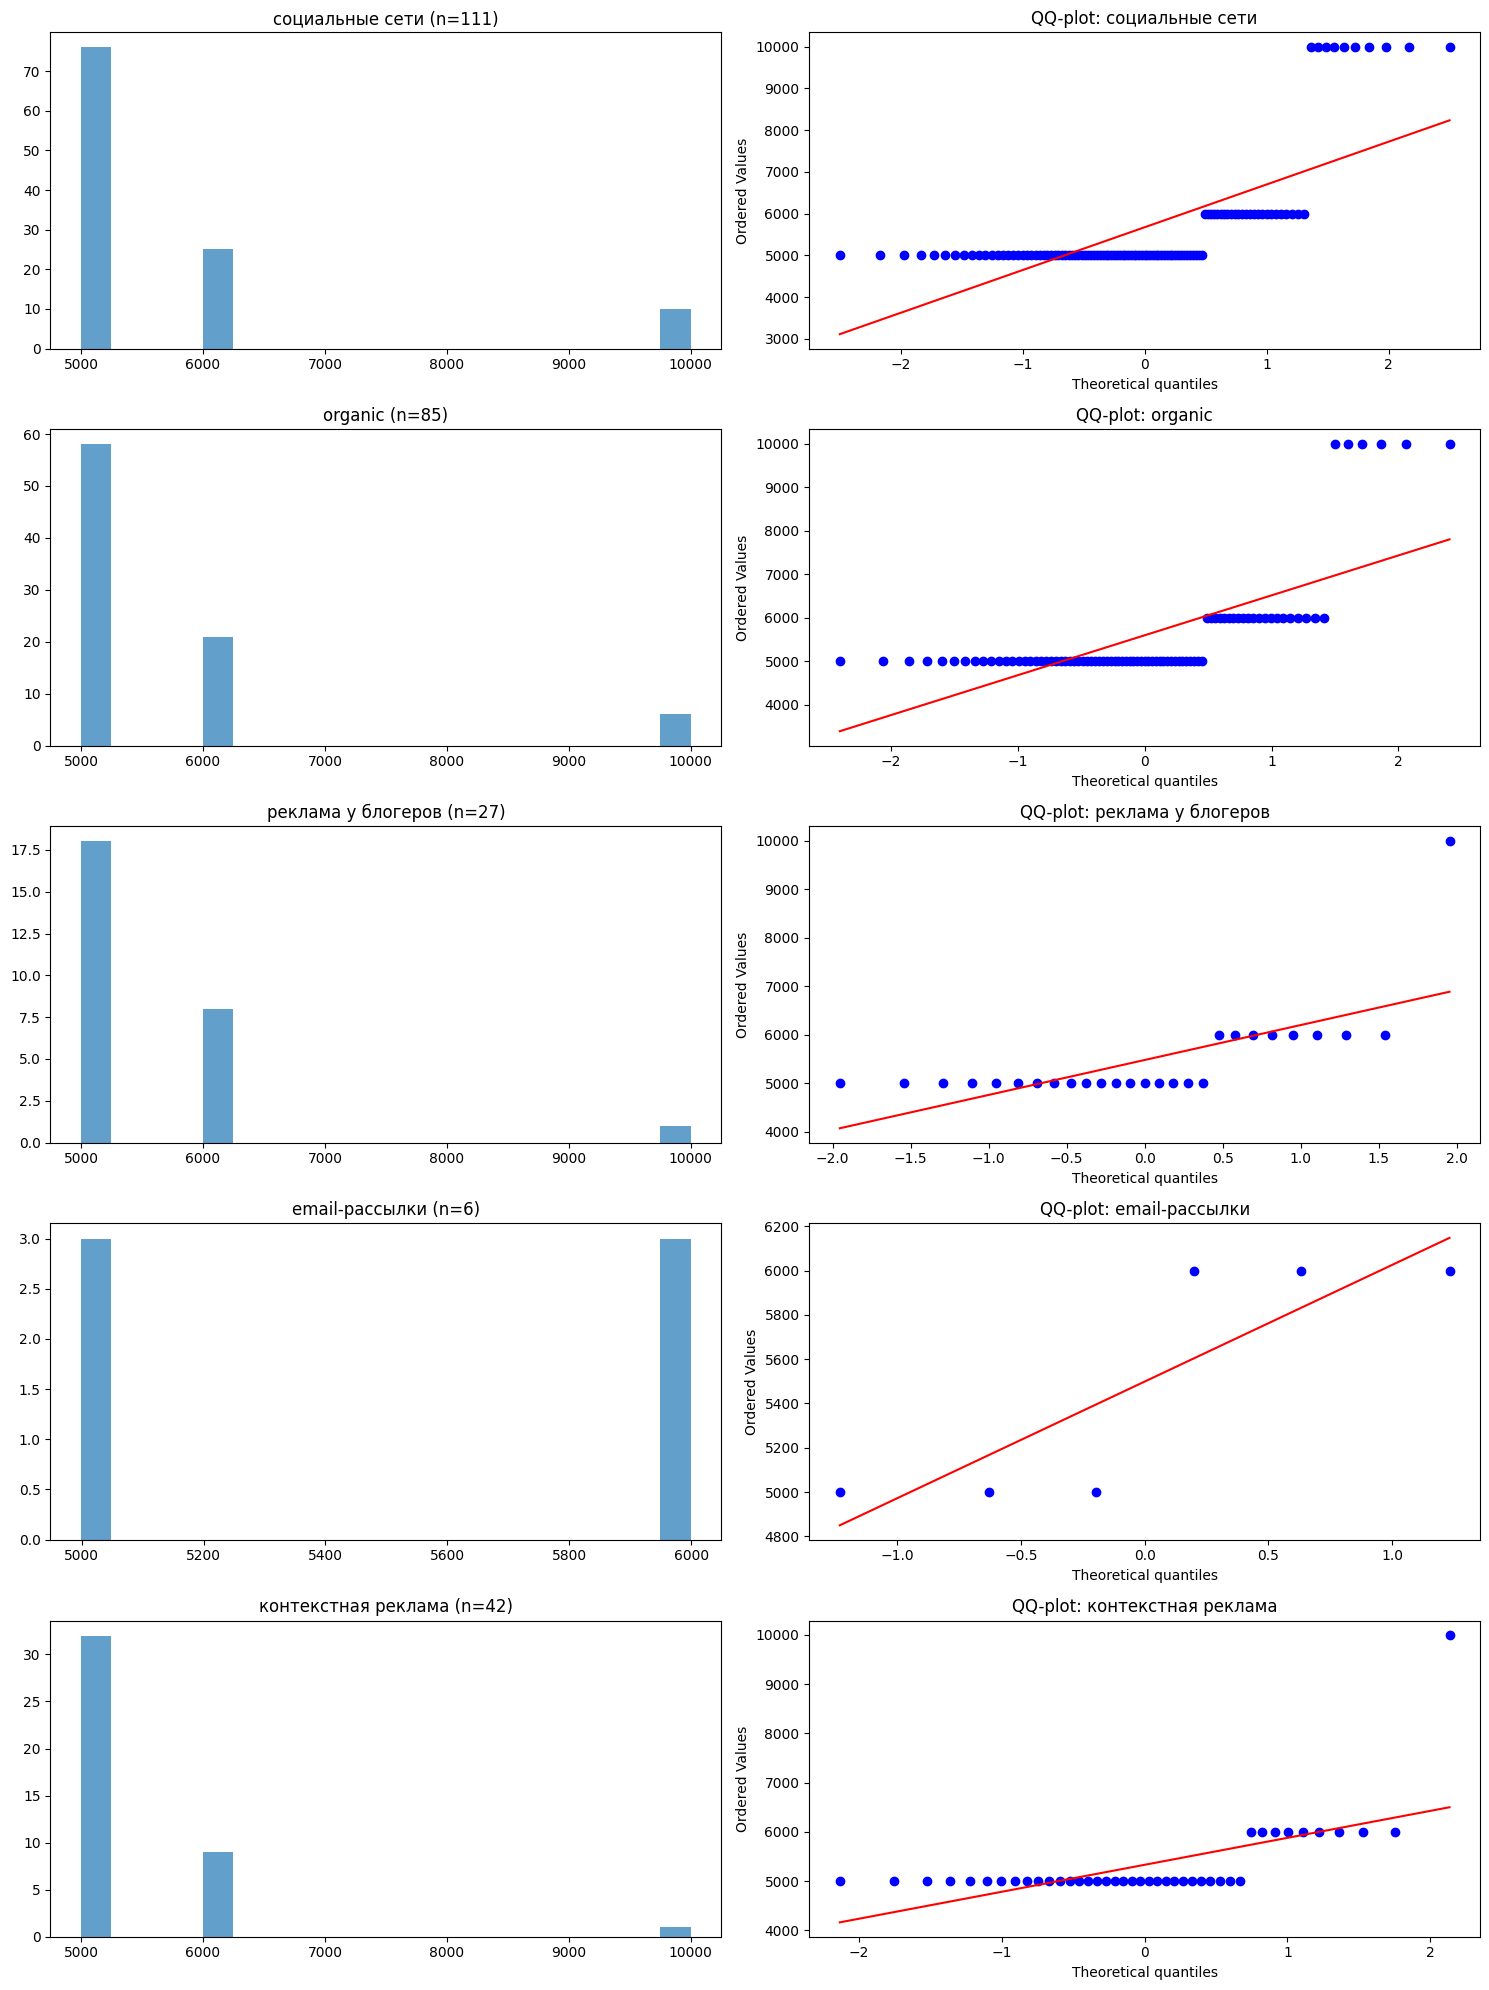

p_value: 0.7304694618075087
Не отвергаем H0, нет значимых различий между средними чеками


In [218]:


channel_and_mean_check = df_sales.groupby('channel').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

channel_and_mean_check.plot(kind='bar')
plt.title('Средний чек по рекламным каналам')
plt.xlabel('Channel')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='channel', y='final_revenue', data=df_sales)
plt.title('Распределение final_revenue по рекламным каналам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# по графикам видим, что есть выбросы. исключим самые больше из них
without_emissions = df_sales[df_sales['final_revenue'] <= 10000]

channel_and_mean_check = without_emissions.groupby('channel').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

channel_and_mean_check.plot(kind='bar')
plt.title('Средний чек по рекламным каналам без значительных выбросов')
plt.xlabel('Channel')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='channel', y='final_revenue', data=without_emissions)
plt.title('Распределение final_revenue по рекламным каналам без значительных выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def simple_plot_groups(df, group_col, value_col):
    groups = df[group_col].unique()
    fig, axes = plt.subplots(len(groups), 2, figsize=(15, 4*len(groups)))
    
    for i, group in enumerate(groups):
        data = df[df[group_col] == group][value_col]
        
        axes[i, 0].hist(data, bins=20, alpha=0.7)
        axes[i, 0].set_title(f'{group} (n={len(data)})')
        
        stats.probplot(data, dist="norm", plot=axes[i, 1])
        axes[i, 1].set_title(f'QQ-plot: {group}')
    
    plt.tight_layout()
    plt.show()

simple_plot_groups(without_emissions, 'channel', 'final_revenue')

# благодаря графическому анализу видим, что данные распределены ненормально.
# количество уровней в категориальной шкале: 5 
# поэтому выбрали критерий Краскела-Уоллеса

channels_data = without_emissions.groupby('channel')['final_revenue'].apply(list).tolist()
_, p_value = stats.kruskal(*channels_data)

print("p_value:", p_value)
if p_value < 0.05:
    print("Отвергаем H0, средний чек отличается в зависимости от рекламного канала")
else:
    print("Не отвергаем H0, нет значимых различий между средними чеками")

После исключегния значительных выбросов видим, что ни графики, ни тесты не подтверждают альтернативную гипотезу, соотвественно средний чек не отличается в зависимости от рекламного канала

#### Проверить гипотезу о том, что средний чек отличается в зависимости от времени суток? 

H0 - средний чек не отличается в зависимости от времени суток  \
H1 - средний чек отличается в зависимости от времени суток  \
фактор - время суток (категориальная), отклик (количесвтенная) - средний чек (весь доход с канала на кол-во покупок в нем)  \

так как шкалы фактора и отклика различаются, нужно определить нормальность распределения данных в группах

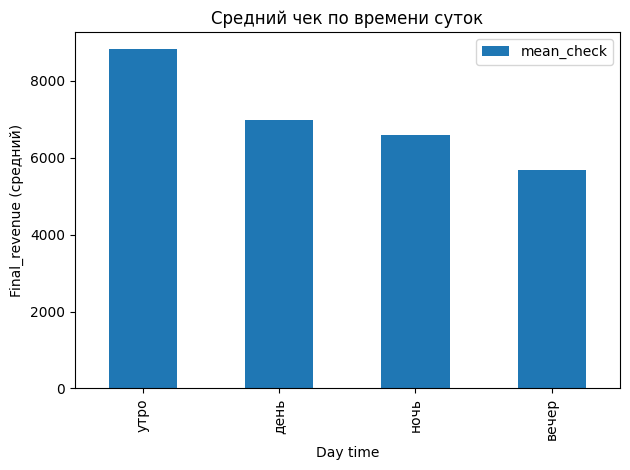

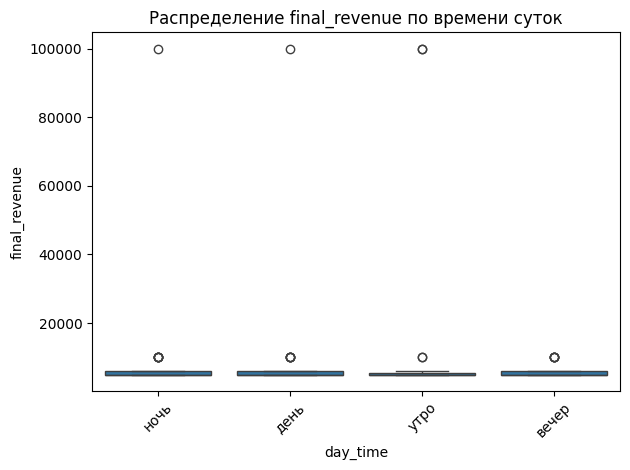

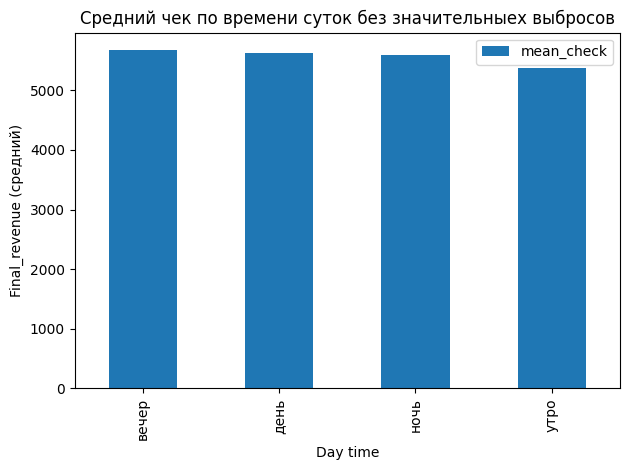

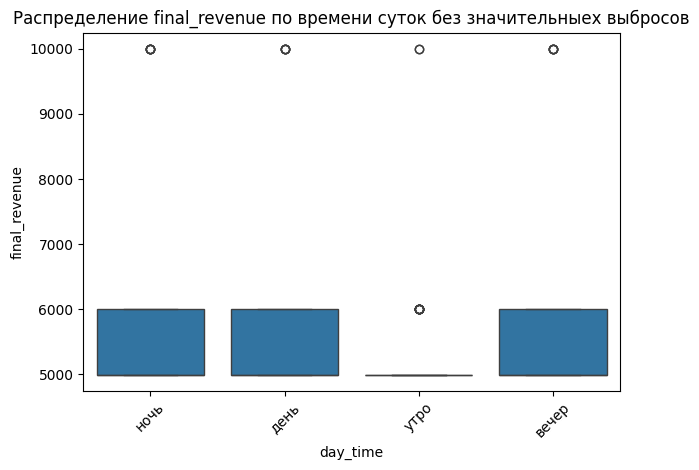

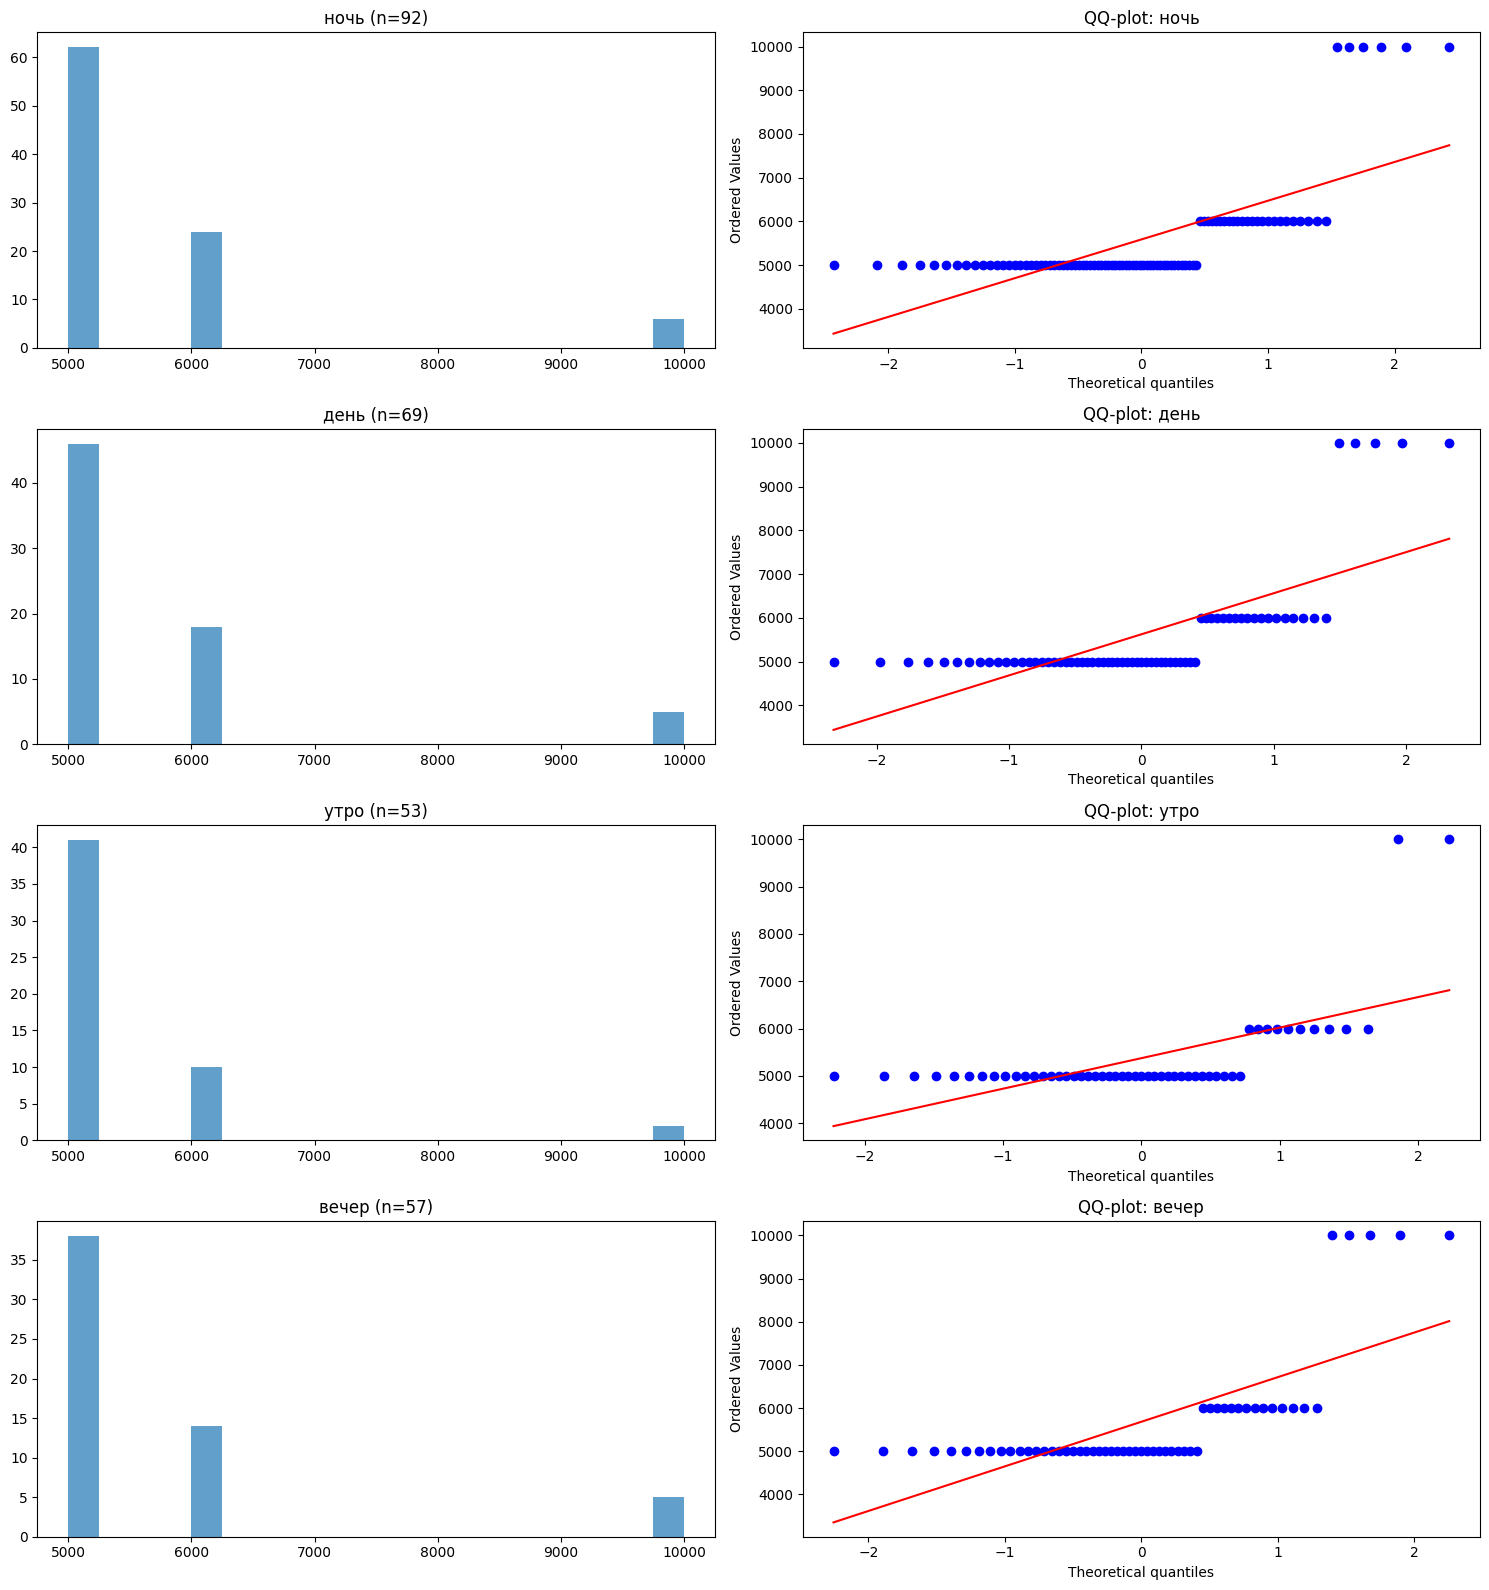

p_value: 0.5130449149586962
Не отвергаем H0, нет значимых различий между средними чеками


In [219]:

daytime_and_mean_check = df_sales.groupby('day_time').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

daytime_and_mean_check.plot(kind='bar')
plt.title('Средний чек по времени суток')
plt.xlabel('Day time')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='day_time', y='final_revenue', data=df_sales)
plt.title('Распределение final_revenue по времени суток')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# по графикам видим, что есть выбросы. исключим самые больше из них
without_emissions = df_sales[df_sales['final_revenue'] <= 10000]

daytime_and_mean_check = without_emissions.groupby('day_time').agg({'final_revenue' : 'mean'}).rename(
    columns={'final_revenue':'mean_check'}).sort_values(by='mean_check',ascending=False)

daytime_and_mean_check.plot(kind='bar')
plt.title('Средний чек по времени суток без значительныех выбросов')
plt.xlabel('Day time')
plt.ylabel('Final_revenue (средний)')
plt.tight_layout()
plt.show()

sns.boxplot(x='day_time', y='final_revenue', data=without_emissions)
plt.title('Распределение final_revenue по времени суток без значительныех выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def simple_plot_groups(df, group_col, value_col):
    groups = df[group_col].unique()
    fig, axes = plt.subplots(len(groups), 2, figsize=(15, 4*len(groups)))
    
    for i, group in enumerate(groups):
        data = df[df[group_col] == group][value_col]
        
        axes[i, 0].hist(data, bins=20, alpha=0.7)
        axes[i, 0].set_title(f'{group} (n={len(data)})')
        
        stats.probplot(data, dist="norm", plot=axes[i, 1])
        axes[i, 1].set_title(f'QQ-plot: {group}')
    
    plt.tight_layout()
    plt.show()

simple_plot_groups(without_emissions, 'day_time', 'final_revenue')

# благодаря графическому анализу видим, что данные распределены ненормально.
# количество уровней в категориальной шкале: 4 
# поэтому выбрали критерий Краскела-Уоллеса

daytime_data = without_emissions.groupby('day_time')['final_revenue'].apply(list).tolist()
_, p_value = stats.kruskal(*daytime_data)

print("p_value:", p_value)
if p_value < 0.05:
    print("Отвергаем H0, средний чек отличается в зависимости от времени суток")
else:
    print("Не отвергаем H0, нет значимых различий между средними чеками")

Альтернативная гипотеза снова не подтверждена, то есть средний чек не отличается в зависимости от времени суток

#### Есть ли взаимосвязь между продолжительностью сессии с суммой покупок?

H0 - взаимосвязь между продолжительностью сессии и суммой покупок отсутствует  \
H1 - взаимосвязь между продолжительностью сессии и суммой покупок присутствует  \
фактор - продолжительность сессии, отклик - сумма покупок, у обоих одинаковая шкала - количесвтенная  \
должны проверить нормальность распределния

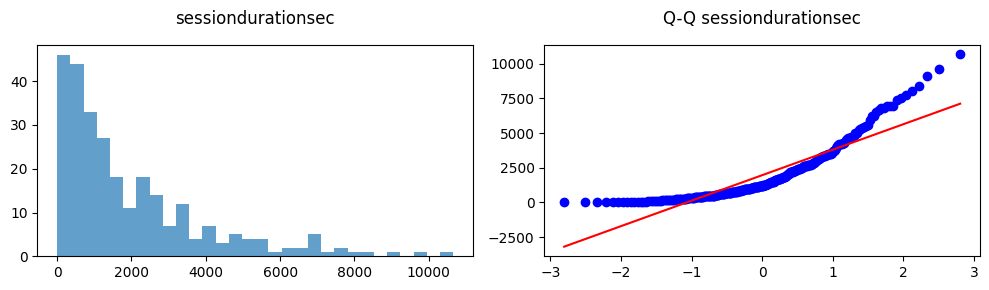

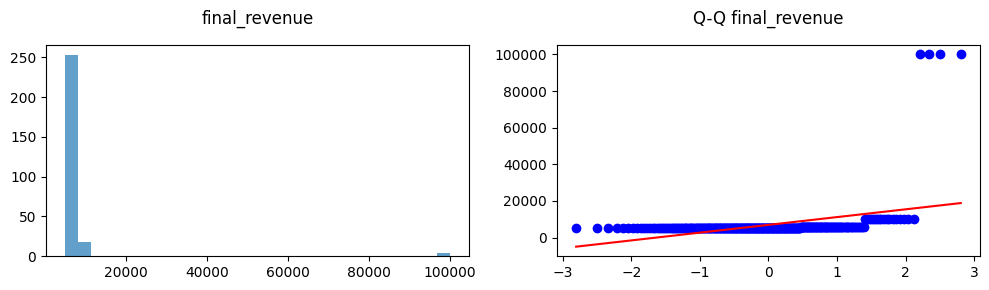

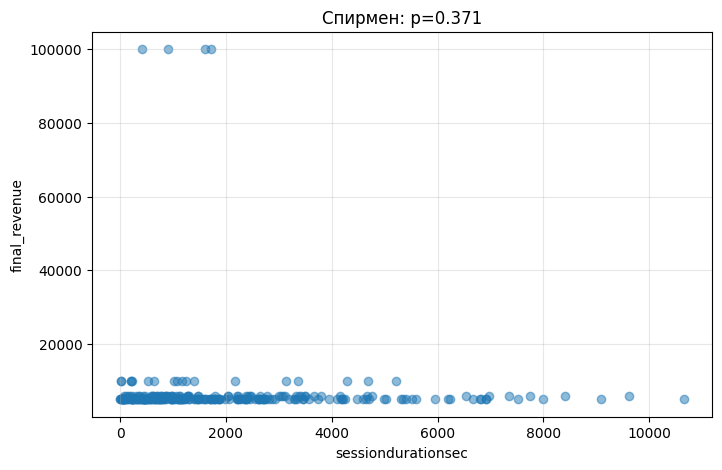

p = 0.37099315426557167 > 0.05, тогда H0 гипотеза подтверждена: взаимосвязь между продолжительностью сессии и суммой покупок отсутсвует


In [220]:

def norm_plots(data, cols):
    for col in cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
        
        ax1.hist(data[col], bins=30, alpha=0.7)
        ax1.set_title(f'{col}', pad=15)

        stats.probplot(data[col], dist="norm", plot=ax2)
        ax2.set_title('')
        ax2.set_title(f'Q-Q {col}', pad=15)

        ax1.set_xlabel('')
        ax1.set_ylabel('')
        ax2.set_xlabel('')
        ax2.set_ylabel('')
        
        plt.tight_layout()
        plt.show()

norm_plots(df_sales, ['sessiondurationsec', 'final_revenue'])

# по графикам видим, что распределение ненормальное в обоих признаках, поэтому используем корреляцию спирмена

plt.figure(figsize=(8, 5))
plt.scatter(df_sales['sessiondurationsec'], df_sales['final_revenue'], alpha=0.5)
plt.xlabel('sessiondurationsec')
plt.ylabel('final_revenue')
_, p = stats.spearmanr(df_sales['sessiondurationsec'], df_sales['final_revenue'])
plt.title(f'Спирмен: p={p:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

if p < 0.05:
    print(f'p = {p} < 0.05, тогда H0 гипотеза опровергнута: взаимосвязь между продолжительностью сессии и суммой покупок присутствует')
else:
    print(f'p = {p} > 0.05, тогда H0 гипотеза подтверждена: взаимосвязь между продолжительностью сессии и суммой покупок отсутсвует')

Подтверждена нулевая гипотеза. Взаимосвязь между продолжительностью сессии и суммой покупок отсутствует.

#### Придумать и проверить еще не менее 2 гипотез, на основании гипотез команды.

#### 1) Влияет ли рекламный канал на конверсию

H0 - рекламный канал не влияет на конверсию  \
Н1 - рекламный канал влияет на конверсию  \
Рекламный канал - категориальный тип данных  \
Конверсия - доля в биноминальном столбце: payer

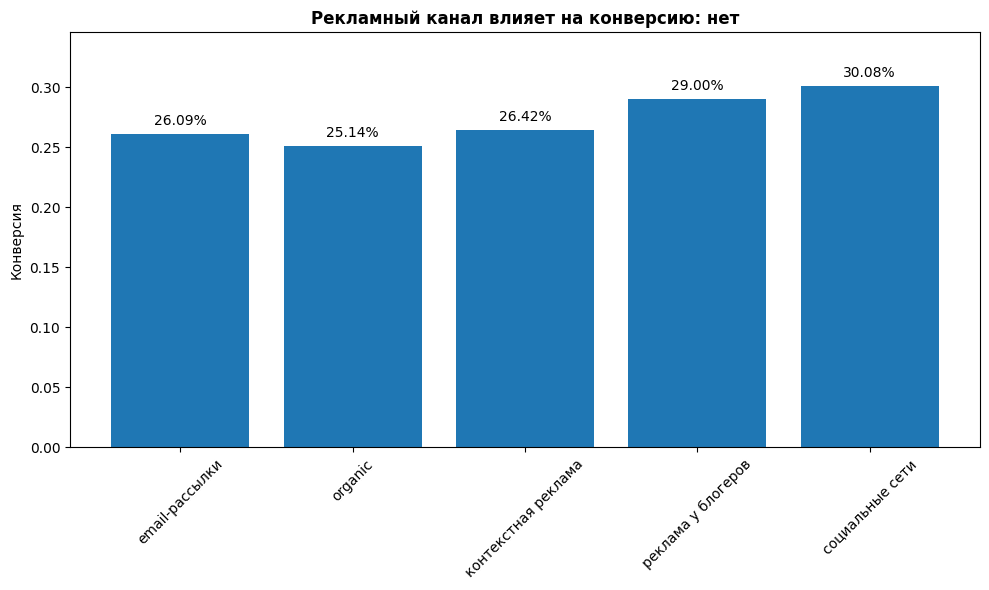

In [221]:
channel_conversion = df.groupby('channel')['payer'].agg(['sum', 'count'])
channel_conversion['rate'] = channel_conversion['sum'] / channel_conversion['count']

channels = channel_conversion.index.tolist()
pairs = list(itertools.combinations(channels, 2))

significant = False
for ch1, ch2 in pairs:
    count = [channel_conversion.loc[ch1, 'sum'], channel_conversion.loc[ch2, 'sum']]
    nobs = [channel_conversion.loc[ch1, 'count'], channel_conversion.loc[ch2, 'count']]
    stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    if pval < 0.05:
        significant = True
        break

plt.figure(figsize=(10, 6))
bars = plt.bar(channel_conversion.index, channel_conversion['rate'])
plt.title(f'Рекламный канал влияет на конверсию: {"да" if significant else "нет"}', fontweight='bold')
plt.ylabel('Конверсия') 
plt.xticks(rotation=45)

max_rate = channel_conversion['rate'].max()
plt.ylim(0, max_rate * 1.15)

for bar, rate in zip(bars, channel_conversion['rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{rate:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Промокод вляет на конверсию.


#### 2) Тип устройства влияет на конверсию

H0 - тип устройства не влияет на конверсию  \
Н1 - тип устройства влияет на конверсию  \
тип устройства - категориальный тип данных  \
Конверсия - доля в биноминальном столбце: payer

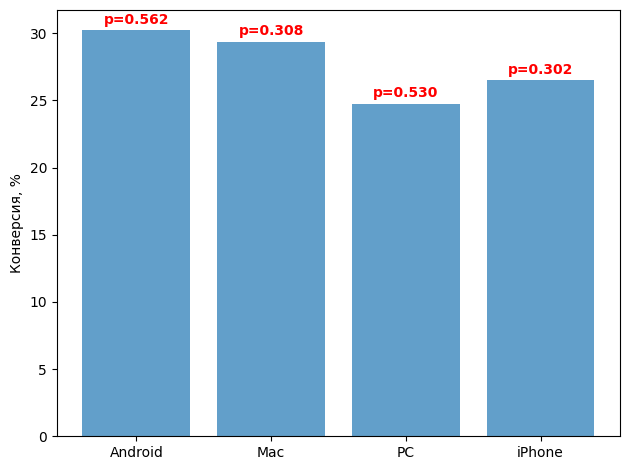

In [222]:
z_stats, p_values = [], []
for device in df['device'].unique():
    device_data = df[df['device'] == device]
    other_data = df[df['device'] != device]
    
    device_conv = device_data['payer'].sum()
    device_total = len(device_data)
    other_conv = other_data['payer'].sum()
    other_total = len(other_data)
    
    zstat, pvalue = proportions_ztest([device_conv, other_conv], [device_total, other_total])
    z_stats.append(zstat)
    p_values.append(pvalue)

conv_rates = df.groupby('device')['payer'].mean() * 100

plt.bar(conv_rates.index, conv_rates.values, alpha=0.7)
plt.ylabel('Конверсия, %')

for i, (dev, p_val) in enumerate(zip(conv_rates.index, p_values)):
    plt.text(i, conv_rates.iloc[i] + 0.5, f'p={p_val:.3f}', ha='center', 
             fontweight='bold', color='green' if p_val < 0.05 else 'red')
    
plt.tight_layout()
plt.show()

Тип устройства не влияет на конверсию

В ходе проверки гипотез было установлено: 
1) тип устройства, тип рекламного канала не влияют на количество покупок в день
2) средние чеки не отличаются в зависимости от региона, рекламного канала и времени суток
3) взаимосвязь между продолжительностью сессии и суммой покупок не была выявлена.  \
Также были выдвинуты и проверены наши гипотезы, в ходе которых выявлено:
1) рекламный канал не влияет на конверсию
2) тип устройства не влияет на конверсию

#### Прогнозирование дальнейших продаж

In [223]:
channel_group = df.groupby(['channel', 'region'])
result = pd.DataFrame({
    'payer_rate': channel_group['payer'].mean(),
    'total_users': channel_group['user_id'].count(),
    'total_revenue': channel_group['final_revenue'].sum(),
    'revenue_rate': channel_group['final_revenue'].sum() / df['final_revenue'].sum(),
    'min_date': channel_group['session_start'].min(),
    'max_date': channel_group['session_start'].max()
})
result.head(30)

payer_rate  total_users  total_revenue  \
channel             region                                                  
email-рассылки      France           0.272727           11        17997.0   
                    Germany          0.200000            5         4999.0   
                    UK               0.285714            7         9998.0   
organic             France           0.100000           30       111998.0   
                    Germany          0.235294           34        46992.0   
                    UK               0.264706           34       155992.0   
                    United States    0.270161          248       360933.0   
контекстная реклама France           0.279070           43        62988.0   
                    Germany          0.209302           43        46991.0   
                    UK               0.294118           51        77985.0   
                    United States    0.272727           22        35994.0   
реклама у блогеров  France           0.368421           19       130994.0   
                    Germany          0.300000           20        32994.0   
                    UK               0.260870           23        30994.0   
                    United States    0.263158           38       152991.0   
социальные сети     United States    0.300813          369       629889.0   

                                   revenue_rate            min_date  \
channel             region                                            
email-рассылки      France             0.009419 2019-05-13 22:00:41   
                    Germany            0.002616 2019-05-06 17:57:38   
                    UK                 0.005233 2019-05-25 20:16:44   
organic             France             0.058615 2019-05-03 07:58:24   
                    Germany            0.024594 2019-05-03 10:48:10   
                    UK                 0.081640 2019-05-03 09:28:23   
                    United States      0.188898 2019-05-01 06:56:16   
контекстная реклама France             0.032965 2019-05-15 20:18:19   
                    Germany            0.024593 2019-05-04 07:33:33   
                    UK                 0.040814 2019-05-18 06:10:12   
                    United States      0.018838 2019-05-09 07:47:12   
реклама у блогеров  France             0.068557 2019-05-02 10:21:30   
                    Germany            0.017268 2019-06-09 22:34:12   
                    UK                 0.016221 2019-05-06 15:01:55   
                    United States      0.080069 2019-05-03 19:48:35   
социальные сети     United States      0.329659 2019-05-01 00:06:40   

                                             max_date  
channel             region                             
email-рассылки      France        2019-10-27 18:49:48  
                    Germany       2019-10-27 06:47:27  
                    UK            2019-10-27 12:01:01  
organic             France        2019-10-30 03:18:22  
                    Germany       2019-10-04 06:41:12  
                    UK            2019-10-27 02:01:54  
                    United States 2019-10-31 16:05:38  
контекстная реклама France        2019-10-26 05:15:54  
                    Germany       2019-10-27 06:11:15  
                    UK            2019-10-24 07:34:20  
                    United States 2019-10-15 23:12:49  
реклама у блогеров  France        2019-10-24 22:30:31  
                    Germany       2019-10-30 19:14:02  
                    UK            2019-10-25 20:31:39  
                    United States 2019-10-26 10:49:20  
социальные сети     United States 2019-10-31 22:56:17

Можем увидеть, что наилучшие соотношения пользователь перешедший / пользователь купивший у канала "реклама у блогеров" во Франции и Германии, а также у канала "социальные сети" в США. Из предыдуших исследований мы можем увидеть, что количество покупателей в США, а следовательно и доходом с продаж, значительно больше, чем в других страннах. Это может быть связа с некоторыми факторами: в целом бОльшим количеством населения в стране, большим спросом на товары компании и другими.
Посчитаем общие затраты на рекламу и их окупаемость. Для этого дополнительно найдём данные о стоимости каждого из каналов привлечения.

Реклама в социальных сетях

Т.к. в 2019 второй по количеству пользователей площадкой является youtube, то будем рассматривать рекламу в этой социальной сети YouTube Adds.
По данным интернет ресурса linxdigital.com (статья: https://linxdigital.com/blog/clickthrough-rate-ctr) средний ctr(кликабельность) рекламы в среднем составляет 1,5%, на сайт магазина перешло 369 пользователей, тогда всего рекламу просмотрело (не менее 30 сек) 24600 человек. Каждый просмотр в США в 2019 году стоил прмерно 0,1$, тогда общая стоимость показа составила 2460$. Предположим, что компания также потратила около 1700$ на съёмку рекламного ролика (https://www.travisduncan.com/blog-advertising-photographer-missouri-travisduncan/tag/How+to+film+a+commercial+for+my+business#:~:text=The%20cost%20to%20produce%20a,answer%20to%20your%20initial%20goal.), тогда общий бюджет на этот канал составлял 4160$, а каждый привлечённый пользователь обошёлся в 11,3$

Реклама у блогеров

Также возьмём youtube как площадку, на которой закупалась реклама у блогеров. Так как нам известно, что она стоит дешевле, чем реклама в социальных сетях, а точные расценки варьируются от канала к каналу, то допустим, что Delivery Dron заплатили за 4 видео с интеграцией у техно-блогеров из 4 стран с количеством подписчиков от 5 тыс. до 50 тыс. в начале мая 2019 года. Тогда каждое видео обошлось примерно в 250$ (https://www.quora.com/How-much-does-it-cost-to-being-advertised-on-famous-YouTube-channels-videos-paying-the-YouTuber), то есть сумарно было потрачено 1000$ + предоставление  товара на обзор (если товар предоставлен с условием возвращения, то компания не тратит на это деньги). Тогда каждый привлечённый к нам пользователь стоил 10$

Контекстная реклама

Точных данных о стоимости одного привлечения пользователя на сайт найти не удалось, но т.к. в тз сказано, что контекстная реклама является самым дорогим каналом, то предположим, что стоимость привлечения составляет 12,5$. Тогда общие затраты на этот рекламный канал - 1987,5$

E-mail рассылка

Так как ctr в 2019 году был в среднем на уровне 2,69% (https://ppc.land/email-marketing-average-open-rate-was-17-92-in-2019/), то с учётом того, что по этому каналу на сайт перешло 23 пользователя, то всего было отправлено 855 писем. Так как средняя стоимость отправки 1 письма составляет 0,02$, то на привлечение было потрачено 17,1$, что также составляет 0,74$ за одного привлечённого пользователя
Добавим эти данные в таблицу в столбец click_cost. Общий бюджет, выделенный на рекламу, за полгода составлял 7164,6$, округлим до 7200$, тогда в год это 14400$, в неделю это около 277$

In [224]:
new_column = []
for index, row in df.iterrows():
    if row['channel'] == 'email-рассылки':
        new_column.append(0.74)
    elif row['channel'] == 'organic':
        new_column.append(0)
    elif row['channel'] == 'контекстная реклама':
        new_column.append(12.5)
    elif row['channel'] == 'социальные сети':
        new_column.append(11.3)
    else:
        if row['region'] == 'France':
            new_column.append(250 / len(df[(df['channel'] == 'реклама у блогеров') & (df['region'] == 'France')])) # разделим стоимость рекламы от блогеров, 
                                                                                                                #так как запись видео скорее всего была на языке страны потребителя
        elif row['region'] == 'Germany':
            new_column.append(250 / len(df[(df['channel'] == 'реклама у блогеров') & (df['region'] == 'Germany')]))
        else:
            new_column.append(500 / len(df[(df['channel'] == 'реклама у блогеров') & ((df['region'] == 'UK') | (df['region'] == 'United States'))]))
df['click_cost'] = new_column
df.head(10)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,final_revenue,day_time,payer,click_cost
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0,9999.0,ночь,1,11.300000
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.0,2019-05-01,5,3,7,NaT,NaN,NaN,0,NaN,утро,0,0.000000
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.0,2019-05-01,5,3,4,NaT,NaN,NaN,0,NaN,ночь,0,11.300000
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.0,2019-05-01,5,3,18,NaT,NaN,NaN,0,NaN,вечер,0,11.300000
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.0,2019-05-02,5,4,14,NaT,NaN,NaN,0,NaN,день,0,11.300000
5,271758921583,United States,iPhone,социальные сети,2019-05-02 08:40:35,2019-05-02 08:41:15,40.0,2019-05-02,5,4,8,NaT,NaN,NaN,0,NaN,утро,0,11.300000
6,425357155257,United States,Android,социальные сети,2019-05-02 16:32:29,2019-05-02 16:55:30,1381.0,2019-05-02,5,4,16,NaT,NaN,NaN,0,NaN,день,0,11.300000
7,768721432035,France,Mac,реклама у блогеров,2019-05-02 10:21:30,2019-05-02 10:51:54,1824.0,2019-05-02,5,4,10,NaT,NaN,NaN,0,NaN,день,0,13.157895
8,177410811849,United States,Android,социальные сети,2019-05-03 18:43:49,2019-05-03 19:30:52,2823.0,2019-05-03,5,5,19,NaT,NaN,NaN,0,NaN,вечер,0,11.300000
9,337713702816,United States,iPhone,реклама у блогеров,2019-05-03 19:48:35,2019-05-03 20:16:10,1655.0,2019-05-03,5,5,20,NaT,NaN,NaN,0,NaN,вечер,0,8.196721


In [225]:
#Построим модель по продажам за неделю, т.к. имеем данные только за полгода, брать больший период(месяц, квартал) не имеет смысла, т.к. тогда модель будет обучаться на 6 строчкахя
df['week'] = df['session_date'].dt.isocalendar().week
df = df[df['revenue'] != 100000]
grouped = df.groupby(['week','channel', 'region'])
df_for_model = pd.DataFrame({
    'ad_budget': grouped['click_cost'].sum(),
    'total_users': grouped['user_id'].count(),
    'total_revenue': grouped['final_revenue'].sum(),
    'total_purchases': grouped['final_revenue'].count()
}).reset_index()
df_for_model = df_for_model[df_for_model['ad_budget'] > 0] # т.к. нам нужно узнать куда вкладывать деньги, то доходы от пользователей, которые сами нашли магазин, не учитываем
df_for_model['region_channel'] = df_for_model['region'] + ' | ' + df_for_model['channel']
print(df_for_model['total_revenue'].describe())

count      177.000000
mean      5846.406780
std       9991.682097
min          0.000000
25%          0.000000
50%          0.000000
75%       5999.000000
max      57990.000000
Name: total_revenue, dtype: float64


Подготовили датафрейм, на основе которого будем строить регрессионные модели. Будем предсказывать общий доход и пользователей, совершивших покупку, по группе регион + канал. 
Для прогназирования в качестве факторов возьмём бюджет, который мы готовы инвестировать в определённый рекламный канал и страну и саму комбинацию канал + страна. Другие показатели не взяты в качестве факторов, т.к. мы изначально не можем предугадать сколько пользовотелей перейдёт на сайт, какие устройства они будут использовать, будет ли введён промокод и т.д. - это незначительные детали, которые не оказывают должного влияния на доход и количество покупателей

0.84 2582.25


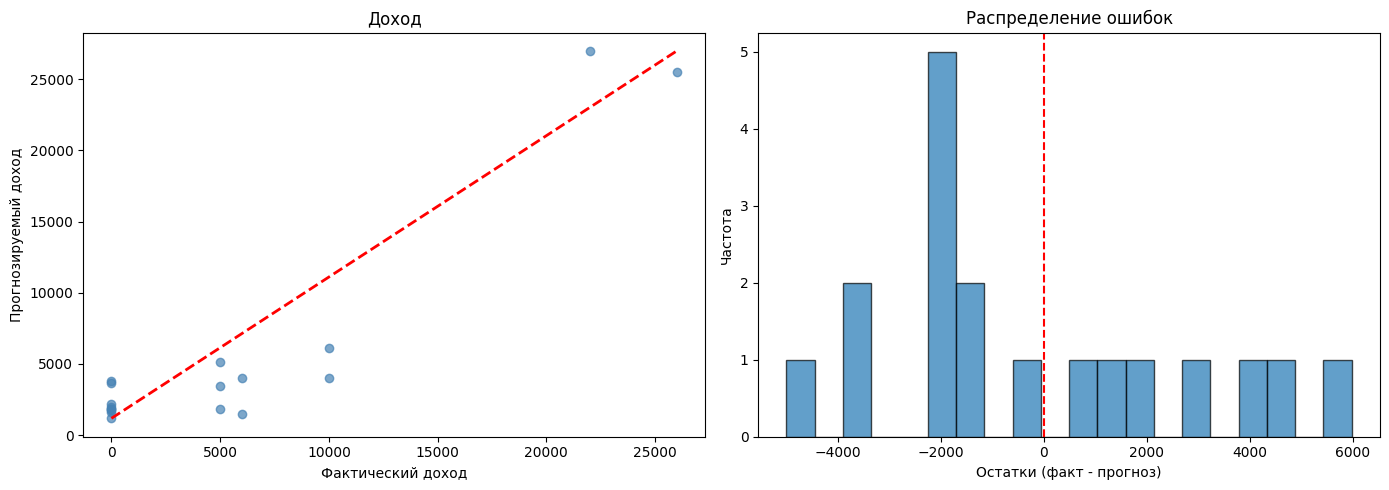

0.84 0.49


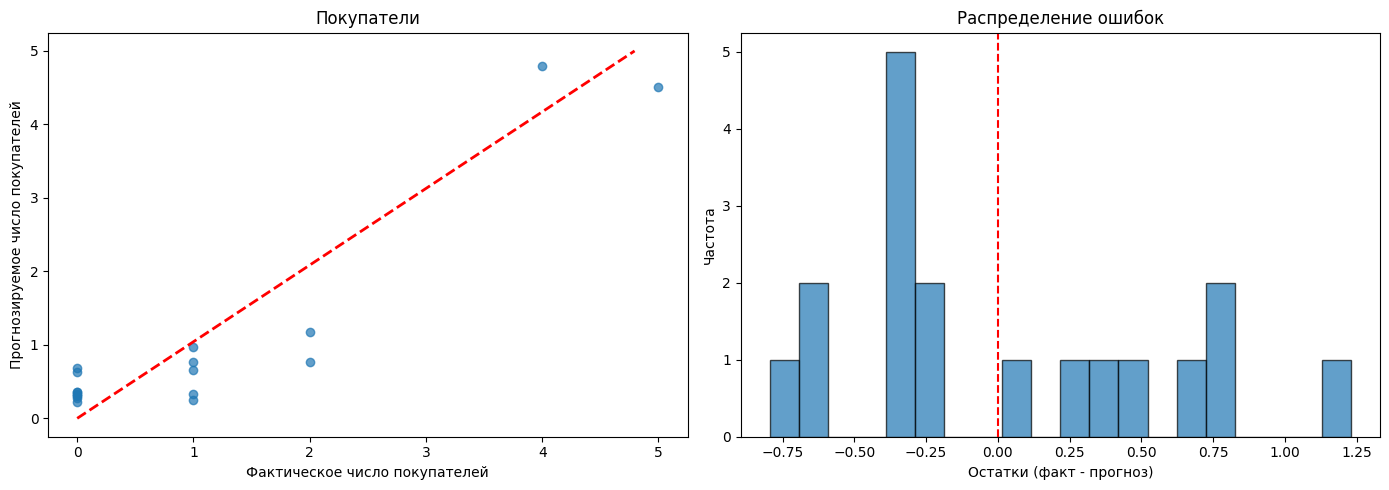

In [226]:
#Строим модели для предсказания дохода и покупателей

factors = df_for_model[['ad_budget', 'region_channel']]
target_revenue = df_for_model['total_revenue']
target_purchases = df_for_model['total_purchases']
x_train, x_test, y_train, y_test = train_test_split(factors, target_revenue, test_size=0.1, random_state=50)
x_train2, x_test2, y_train2, y_test2 = train_test_split(factors, target_purchases, test_size=0.1, random_state=50)
preprocessor = ColumnTransformer(
    transformers=[('region_channel_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), ['region_channel'])], remainder='passthrough'
)
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)
x_train2 = preprocessor.fit_transform(x_train2)
x_test2 = preprocessor.transform(x_test2)

lin_regr_revenue = LinearRegression()
lin_regr_revenue.fit(x_train, y_train)
prediction_revenue = lin_regr_revenue.predict(x_test)
mae = round(mean_absolute_error(y_test, prediction_revenue), 2)
r2 = round(r2_score(y_test, prediction_revenue), 2)
print(r2, mae)
errors_rev = y_test - prediction_revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, prediction_revenue, alpha=0.7, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [prediction_revenue.min(), prediction_revenue.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактический доход')
axes[0].set_ylabel('Прогнозируемый доход')
axes[0].set_title('Доход')

axes[1].hist(errors_rev, bins=20,  edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (факт - прогноз)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок')

plt.tight_layout()
plt.show()

lin_regr_purchases = LinearRegression()
lin_regr_purchases.fit(x_train2, y_train2)
prediction_purchases = lin_regr_purchases.predict(x_test2)
mae = round(mean_absolute_error(y_test2, prediction_purchases), 2)
r2 = round(r2_score(y_test2, prediction_purchases), 2)
print(r2, mae)
errors_purch = y_test2 - prediction_purchases

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test2, prediction_purchases, alpha=0.7)
axes[0].plot([y_test2.min(), prediction_purchases.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактическое число покупателей')
axes[0].set_ylabel('Прогнозируемое число покупателей')
axes[0].set_title('Покупатели')

axes[1].hist(errors_purch, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (факт - прогноз)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок')

plt.tight_layout()
plt.show()

Не можем использовать MAPE, так как в наших предсказаниях присутствуют нулевые значения. Модель объясняет 84% вариации недельного дохода и количества покупателей на основе рекламного бюджета и комбинации «страна + канал».  В среднем прогноз модели отклоняется от фактического дохода менее чем на 2582$, и от покупателей в неделю на 0.5 пользователей. Такой результат является приемлимым, так что будем использовать данную модель для предсказания годового дохода.

In [227]:
def forecast(region, channel, budget):
    segment = f"{region} | {channel}"
    new_data = pd.DataFrame({
        'ad_budget': [budget],
        'region_channel': [segment]
    })
    new_processed = preprocessor.transform(new_data)
    pred_rev = lin_regr_revenue.predict(new_processed)[0]
    pred_purch = lin_regr_purchases.predict(new_processed)[0]
    return {
        'predicted_revenue': max(pred_rev, 0) * 52,
        'predicted_purchasers': max(pred_purch, 0) * 52
    }

In [228]:
forecast_results = []
for i in df['region'].unique():
    for j in df['channel'].unique():
        if j != 'organic' and not (j == "социальные сети" and i != "United States") and not(j == "email-рассылки" and i == "United States"):
            results = forecast(i, j, 277)
            revenue = results['predicted_revenue']
            purchasers = results['predicted_purchasers']
            forecast_results.append({
            'region': i,
            'channel': j,
            'predicted_purchasers': purchasers,
            'predicted_revenue': revenue
        })
            print(f'Для {i} + {j} количество покупателей составит {purchasers} за следующий год, а общий доход - {revenue}')
results_df = pd.DataFrame(forecast_results)
best_by_revenue = results_df.loc[results_df['predicted_revenue'].idxmax()]
best_by_purchasers = results_df.loc[results_df['predicted_purchasers'].idxmax()]

print("ЛУЧШИЙ СЕГМЕНТ ПО ДОХОДУ:")
print(f"  Регион: {best_by_revenue['region']}")
print(f"  Канал: {best_by_revenue['channel']}")
print(f"  Доход: {best_by_revenue['predicted_revenue']:,.2f}")
print(f"  Покупатели: {best_by_revenue['predicted_purchasers']:.2f}")

print("ЛУЧШИЙ СЕГМЕНТ ПО ПОКУПАТЕЛЯМ:")
print(f"  Регион: {best_by_purchasers['region']}")
print(f"  Канал: {best_by_purchasers['channel']}")
print(f"  Покупатели: {best_by_purchasers['predicted_purchasers']:.2f}")
print(f"  Доход: {best_by_purchasers['predicted_revenue']:,.2f}")


results = forecast('United States', 'социальные сети', 138.5)
results2 = forecast('UK', 'реклама у блогеров', 138.5)
revenue = results['predicted_revenue'] + results2['predicted_revenue']
purchasers = results['predicted_purchasers'] + results2['predicted_purchasers']
print("При кросс-канальной стратегии Великобритания+США")
print(f"  Покупатели: {purchasers:.2f}")
print(f"  Доход: {revenue:,.2f}")

Для United States + социальные сети количество покупателей составит 376.9470964378169 за следующий год, а общий доход - 2066824.0784764776
Для United States + реклама у блогеров количество покупателей составит 371.0952531949094 за следующий год, а общий доход - 1944143.5125914211
Для United States + контекстная реклама количество покупателей составит 367.11029539424845 за следующий год, а общий доход - 1935831.6737777432
Для France + реклама у блогеров количество покупателей составит 368.54045710872356 за следующий год, а общий доход - 1914767.0725616089
Для France + контекстная реклама количество покупателей составит 357.74793147681555 за следующий год, а общий доход - 1860125.701581919
Для France + email-рассылки количество покупателей составит 379.2222891636906 за следующий год, а общий доход - 1981416.9692691914
Для Germany + реклама у блогеров количество покупателей составит 369.60018652527344 за следующий год, а общий доход - 1927711.4310508128
Для Germany + контекстная реклама к

Предсказание модели свидетельствует о том, что наиболее прибыльными являются сочетания США + реклама в социальных сетях и Великобритания + реклама у блогеров, при комбинировании этих двух каналов получим наибольший доход от рекламных каналов в 2093136$